# JAX — NumPy that compiles, batches and differentiates

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 1 — Computational toolbox*

## 1. Introduction and motivation

**The main computational tool of the course is the JAX library** (Bradbury *et al.*, 2018). The two starter notebooks
[00a — a free Gaussian wave packet](00a_free_particle_gaussian_wave_packet.ipynb) and
[00b — the 1D harmonic oscillator](00b_first_quantum_simulation_harmonic_oscillator.ipynb) used `jnp`, `jit` and
`lax.scan` without explaining them; this notebook explains them. Later notebooks simulate chains of
interacting quantum spins, noisy quantum circuits, quantum sensors and variational algorithms. The state of $N$
spins is a list of $2^N$ complex numbers, so every such simulation is *a very large amount of simple arithmetic on
arrays*, and whether it takes a second or an hour is decided by **how** that arithmetic is organised.

You already know **NumPy**: arrays, slicing, `np.sin`, `np.linalg.eigh`, and the golden rule "avoid Python loops,
use whole-array operations". **JAX** is a Python library that keeps this programming model — its module `jax.numpy`
copies the NumPy interface almost function by function — and adds three things:

| ingredient | what it is | what you gain |
|---|---|---|
| `jax.numpy` | the NumPy interface, re-implemented on top of a compiler | the same code runs on CPU, GPU or TPU |
| **XLA compiler** (`jax.jit`) | your Python function is *traced* once and translated into one optimised machine program | speed: fused loops, no temporaries, no Python overhead |
| **function transformations** | functions that take a function and return a new function: `jit`, `vmap`, `grad`, (and the loop primitive `lax.scan`) | batching over parameters without rewriting code; exact derivatives without deriving them by hand |

Why should a physicist care? Four recurring situations of this course:

* *Time evolution* is a loop of thousands of identical steps → `lax.scan` compiles the step once and runs the loop
  inside the compiled program.
* *Parameter sweeps, disorder realisations, measurement shots, quantum trajectories* are the same computation
  repeated for many inputs → `jax.vmap` turns a function written for **one** sample into a function for a whole batch.
* *Variational methods and fits* need gradients of a simulated quantity with respect to parameters →
  `jax.grad` differentiates straight through the simulation.
* *Stochastic simulations* must be reproducible → JAX has explicit random-number keys instead of a hidden global state.

The price is a small set of rules (pure functions, immutable arrays, no Python `if` on computed values inside
compiled code, …). Newcomers hit the same five or six error messages in their first week. We will **provoke each of
them on purpose**, read the message, and learn the idiom that avoids it.

**Road map.** Section 2 explains the *Configuration* cell that opens every notebook of the course (device, precision).
Sections 3–4 compare `jnp` with `np` (immutability, dtypes, complex numbers) and show how to time JAX code (compile time versus run time). Sections 5–8
introduce the transformations one by one: `jit`, `vmap`, `lax.scan`, `lax.cond`/`jnp.where`. Section 9 is automatic
differentiation, Section 10 random numbers, Sections 11–12 pytrees and the composition of transformations.
Section 13 is a **mini-project with real physics**: a two-level atom driven by a laser (Rabi oscillations),
integrated with `scan`, swept over the detuning with `vmap`, and finally *fitted to noisy synthetic data with
`grad`* — differentiating through the ODE solver. Section 14 collects a "NumPy habit → JAX idiom" table and the list
of common error messages, to which you will return often.

### What you will learn

*Physics*

* the two-level atom in a near-resonant field: Rabi formula, generalised Rabi frequency, the "chevron" pattern
  measured in every qubit laboratory;
* a first variational calculation: the ground state of a single spin found by gradient descent.

*Numerical methods*

* floating-point precision (`float32` vs `float64`), round-off versus truncation error in finite differences;
* explicit ODE integrators (Euler, 4th-order Runge–Kutta), measuring the order of convergence;
* Monte-Carlo estimates and the $1/\sqrt{M}$ law; least-squares fitting by gradient descent.

*Implementation practice*

* `jax.numpy`, immutability and `.at[].set()`, dtypes and the course-wide configuration cell;
* asynchronous dispatch and how to time compiled code (compile time vs run time);
* `jit`, `vmap`, `lax.scan`, `lax.cond`, `grad`/`value_and_grad`, explicit PRNG keys, pytrees, and their composition;
* reading the typical JAX error messages.

### Prerequisites
One semester of quantum mechanics (spin-1/2, Pauli matrices, the Schrödinger equation) and basic NumPy/matplotlib.
**No previous contact with JAX is assumed**, and in particular the two starter notebooks
[00a](00a_free_particle_gaussian_wave_packet.ipynb) and
[00b](00b_first_quantum_simulation_harmonic_oscillator.ipynb) are *not* a prerequisite: they are physics warm-ups
that used JAX without explaining it, and every idiom they borrowed (`jnp`, `.at[].set()`, `jit`, `lax.scan`,
`vmap`) is derived below. The natural continuation is
[02 — index notation and einsum](02_einsum_from_scratch.ipynb).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. The Configuration cell

The cell above opens **every** notebook of this course. Its lines, one by one:

**`DEVICE = "auto"`** — where the arithmetic is executed. JAX can run the same program on a CPU or on an
accelerator (GPU/TPU). With `"auto"` JAX uses a GPU if it finds one and the CPU otherwise. With `"cpu"` the cell
sets the environment variable `JAX_PLATFORMS=cpu`. The comment *"must be set BEFORE jax is imported"* is essential:
JAX decides which hardware back-end to initialise when it starts up, so changing the variable later has no
effect (after changing `DEVICE`, restart the kernel). `"gpu"` only adds a warning if no GPU was found.

**`PRECISION = "double"`** — the floating-point format. A `float64` ("double precision") number has about 16
significant decimal digits, a `float32` ("single") only about 7. *JAX, unlike NumPy, uses 32-bit numbers by default*
(it was born in machine learning, where 7 digits are plenty and GPUs are fastest in single precision). The line

```python
jax.config.update("jax_enable_x64", PRECISION == "double")
```

switches 64-bit support on. It must be executed before the first array is created, which is why it lives in the
first cell. In physics we usually want double precision: we subtract nearly equal energies, we propagate a state
over thousands of time steps, and we validate codes by checking that two results agree to $10^{-10}$.

**`PRECISION = globals().get("PRECISION", ...)`** — this odd-looking line simply keeps the value you chose at the
top of the cell (`globals()` is the dictionary of the variables defined in the notebook). The fall-back to an environment
variable matters only when the same lines are executed outside a notebook; you can ignore it.

**`RDTYPE`, `CDTYPE`** — the real and the complex data type that match the chosen precision
(`float64`/`complex128` or `float32`/`complex64`). Rule of the course: *never hard-code a dtype*; write
`jnp.zeros(n, dtype=CDTYPE)` and the whole notebook follows the switch.

**`TOL`** — the tolerance used in the sanity checks (`assert error < TOL`): $10^{-10}$ in double and $10^{-4}$ in
single precision. A check that demands $10^{-10}$ can never pass with 7-digit arithmetic.

**`_LETTERS`** — the alphabet `a…zA…Z`, used from notebook 02 on to build `einsum` index strings. Not needed today.

**The imports.** `numpy as np` (we keep using NumPy for small set-up work and as a reference), `jax`,
`jax.numpy as jnp` (the convention used by everybody), `lax` (the low-level module containing `scan`, `cond`, …),
`partial` from `functools` (to pre-fill arguments of a function), the standard modules `os`, `string`, `math` and
`time`, and matplotlib.

**The two `print` lines** document the run: JAX version, back-end, devices, precision. When you report a timing or a
bug, this line is the first thing people will ask for.

Let us verify what the cell has done.

In [2]:
# ==============================================================================
# What did the configuration cell do?  Ask JAX directly.
# ==============================================================================
print("64-bit mode enabled     :", jax.config.jax_enable_x64)
print("default real dtype      :", jnp.ones(3).dtype)            # follows the x64 switch
print("default complex dtype   :", (1j * jnp.ones(3)).dtype)
print("RDTYPE, CDTYPE          :", RDTYPE.__name__, CDTYPE.__name__)
print("machine epsilon (RDTYPE):", jnp.finfo(RDTYPE).eps)        # smallest e with 1+e != 1 (roughly)
print("default device          :", jnp.ones(3).device)

64-bit mode enabled     : True


default real dtype      : float64
default complex dtype   : complex128
RDTYPE, CDTYPE          : float64 complex128
machine epsilon (RDTYPE): 2.220446049250313e-16
default device          : cpu:0


With `PRECISION = "double"` a freshly created array is `float64`, exactly as in NumPy, and the machine epsilon is
$2.2\times10^{-16}$.

### What happens without the switch

You *will* meet JAX code without our configuration cell, so you should see the default behaviour once. The context
manager `jax.enable_x64(False)` switches 64-bit support off for the duration of a `with` block (we use it only for
this demonstration). Two things to watch: the default dtype becomes `float32`, and an explicit request for
`float64` is **silently downgraded** — JAX only emits a warning, which we capture and print.

In [3]:
# ==============================================================================
# JAX defaults (no x64): float32 everywhere, float64 requests are truncated
# ==============================================================================
import warnings

with jax.enable_x64(False):
    a = jnp.arange(3.0)
    print("default dtype without x64 :", a.dtype)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        b = jnp.zeros(3, dtype=jnp.float64)                 # we ASK for float64 ...
    print("requested float64, got    :", b.dtype)           # ... and get float32
    print("the warning JAX emits     :", str(caught[0].message)[:118], "...")

default dtype without x64 : float32
requested float64, got    : float32
the warning JAX emits     : Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To ena ...


### Why precision matters: two one-line experiments

1. *Absorption*: adding a small number to a big one. In single precision $1 + 10^{-8}$ **is** $1$.
2. *Catastrophic cancellation*: $g(x) = (1-\cos x)/x^2 \to 1/2$ for $x\to0$. The numerator subtracts two nearly
   equal numbers; the leading digits cancel and only round-off noise survives. At $x=10^{-4}$ we have
   $1-\cos x \approx 5\times10^{-9}$, below the resolution of `float32` — the result is $0$ instead of $0.5$.

Both effects, and floating-point arithmetic in general, are explained in D. Goldberg, ACM Comput. Surv. **23**,
5 (1991).

We force the dtypes explicitly, and switch 64-bit support on locally with the same context manager, so that the
cell shows the same comparison whatever `PRECISION` you selected.

In [4]:
# ==============================================================================
# float32 vs float64: absorption and catastrophic cancellation
# ==============================================================================
with jax.enable_x64(True):                                    # make float64 available here whatever PRECISION is
    for dtype in (jnp.float32, jnp.float64):
        one, tiny, x = dtype(1.0), dtype(1e-8), dtype(1e-4)
        g = (one - jnp.cos(x)) / x**2
        print(f"{jnp.dtype(dtype).name}:  (1 + 1e-8) - 1 = {float((one + tiny) - one):.3e}    "
              f"(1 - cos x)/x^2 at x=1e-4 = {float(g):.6f}")

float32:  (1 + 1e-8) - 1 = 0.000e+00    (1 - cos x)/x^2 at x=1e-4 = 0.000000


float64:  (1 + 1e-8) - 1 = 1.000e-08    (1 - cos x)/x^2 at x=1e-4 = 0.500000


`float32` returns $0$ in both cases; `float64` returns $10^{-8}$ (up to its own 16-digit round-off) and $0.500000$.
The errors of single precision are not always this dramatic, and in return it needs half the memory — a serious
argument when a state vector of 30 spins occupies 16 GB in `complex128`. That is why the switch exists. Our default
is `"double"`.

> **Numerical practice.** Decide the precision *once*, at the top, and derive everything from it (`RDTYPE`, `CDTYPE`,
> `TOL`). Mixed precision that appears by accident — one array created as `float32`, the rest `float64` — is a
> classic source of results that are "almost right".

## 3. `jnp` versus `np`: the same interface, a different kind of array

### 3.1 First contact
Almost every NumPy function exists under the same name in `jax.numpy`. If you can write NumPy you can already
write JAX:

In [5]:
# ==============================================================================
# The same computation in NumPy and in jax.numpy
# ==============================================================================
x_np = np.linspace(0.0, 1.0, 5)
x = jnp.linspace(0.0, 1.0, 5)

print("NumPy :", np.sum(np.sin(x_np) ** 2), type(x_np).__name__)
print("JAX   :", jnp.sum(jnp.sin(x) ** 2), type(x).__name__)
print("x     :", x, "| dtype", x.dtype, "| shape", x.shape, "| lives on", x.device)

# conversions in both directions (on CPU they are cheap; on a GPU they copy data between memories)
back = np.asarray(x)                     # jax.Array  -> numpy.ndarray
forth = jnp.asarray(x_np)                # numpy.ndarray -> jax.Array
print("round trip:", type(back).__name__, "->", type(forth).__name__, "| as Python float:", float(x[1]))

# linear algebra is there too: eigenvalues of the Pauli matrix sigma_x
sigma_x = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
print("eigenvalues of sigma_x:", jnp.linalg.eigvalsh(sigma_x))

NumPy : 1.4637623835604634 ndarray


JAX   : 1.4637623835604634 ArrayImpl
x     : [0.   0.25 0.5  0.75 1.  ] | dtype float64 | shape (5,) | lives on cpu:0


round trip: ndarray -> ArrayImpl | as Python float: 0.25


eigenvalues of sigma_x: [-1.  1.]


The results agree; the *type* of the array differs: a `jax.Array` (its class is called `ArrayImpl`) knows on which
device it lives and can be handed to the compiler. matplotlib, `float()`, `np.asarray` all accept it.

### 3.2 Difference no. 1 — JAX arrays are immutable
In NumPy you modify arrays in place: `x[0] = 5`. JAX forbids this. The reason is the compiler: a function that
*only computes outputs from inputs* and never modifies anything (a **pure function**) can be analysed, reordered,
fused, differentiated and batched safely. In-place modification of shared data would break all of that.

The following helper runs a piece of code that we *expect* to fail and prints the first lines of the error message
instead of stopping the notebook. We will use it throughout to get acquainted with JAX's error messages.

In [6]:
# ==============================================================================
# Helper: provoke an error on purpose and read the message
# ==============================================================================
import re


def show_error(fn, *args, max_lines=1):
    """Call fn(*args); if it raises, print the exception type and the first `max_lines` lines of its message."""
    try:
        fn(*args)
        print("no error raised")
    except Exception as err:                                   # noqa: BLE001  (we WANT to catch everything here)
        lines = [re.sub(r" at \S+:\d+", "", ln) for ln in str(err).strip().splitlines()]   # drop file paths
        print(f"{type(err).__name__}: " + "\n    ".join(lines[:max_lines]))


def assign_in_place(arr):
    arr[0] = 5.0                                               # the NumPy habit


show_error(assign_in_place, jnp.zeros(4))

TypeError: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html


The message already tells us the cure. `x.at[idx]` is an *indexed update* helper: `.set(v)`, `.add(v)`,
`.multiply(v)`, `.min(v)`, `.max(v)` return a **new array** and leave the original untouched.

In [7]:
# ==============================================================================
# Functional updates:  x_new = x.at[index].set(value)
# ==============================================================================
x = jnp.zeros(4, dtype=RDTYPE)
y = x.at[0].set(5.0)                  # like x[0] = 5, but returns a copy
z = y.at[1:3].add(1.0)                # like y[1:3] += 1
print("x (unchanged):", x)
print("y            :", y)
print("z            :", z)

# the quantum state |0> of a spin-1/2: a complex vector with a single 1 -- built the functional way
ket0 = jnp.zeros(2, dtype=CDTYPE).at[0].set(1.0)
print("|0> =", ket0)

x (unchanged): [0. 0. 0. 0.]
y            : [5. 0. 0. 0.]
z            : [5. 1. 1. 0.]


|0> = [1.+0.j 0.+0.j]


A copy for every update sounds expensive. Outside compiled code it is, a little. Inside a `jit`-compiled function
the compiler sees that the old array is never used again and performs the update in place. You get the safety of
functional code and the speed of mutation.

### 3.3 Difference no. 2 — silent out-of-bounds indexing, and no implicit lists
Code running on an accelerator cannot raise a Python exception in the middle of a computation. JAX therefore
defines a behaviour for out-of-range indices instead of raising an error: when *reading*, the index is clamped to
the valid range; when *updating* with `.at[]`, the update is dropped.

In [8]:
# ==============================================================================
# Out-of-bounds indices do NOT raise in JAX
# ==============================================================================
v_np = np.arange(5.0)
v = jnp.arange(5.0)

show_error(lambda: v_np[10])                                   # NumPy: IndexError
print("JAX  v[10]              =", v[10], "  <- clamped to the last element, no error")
print("JAX  v.at[10].set(99.)  =", v.at[10].set(99.0), "  <- update silently dropped")

# JAX functions also refuse Python lists (NumPy converts them silently, which hides performance problems)
show_error(lambda: jnp.sum([1.0, 2.0, 3.0]))
print("explicit conversion works:", jnp.sum(jnp.array([1.0, 2.0, 3.0])))

IndexError: index 10 is out of bounds for axis 0 with size 5


JAX  v[10]              = 4.0   <- clamped to the last element, no error
JAX  v.at[10].set(99.)  = [0. 1. 2. 3. 4.]   <- update silently dropped
TypeError: sum requires ndarray or scalar arguments, got <class 'list'> at position 0.
explicit conversion works: 6.0


> **Common pitfall.** An off-by-one index in NumPy crashes loudly; in JAX it returns a wrong number quietly.
> When you translate a loop with index arithmetic to JAX, test it against a NumPy version on a small example.

### 3.4 Complex numbers
Quantum mechanics lives in complex vector spaces, and JAX handles complex arrays natively. The only thing to
remember is the dtype: an array created from Python integers is an *integer* array, and storing a complex number
into a real array does not make it complex. We therefore always create states and operators with `dtype=CDTYPE`.

As a warm-up with physical content, take the spin state $|\psi\rangle = (|0\rangle + i|1\rangle)/\sqrt2$. It is the
eigenstate of $\sigma_y$ with eigenvalue $+1$, so we must find $\langle\psi|\psi\rangle = 1$ and
$\langle\psi|\sigma_y|\psi\rangle = 1$. The function `jnp.vdot(a, b)` $=\sum_i a_i^* b_i$ complex-conjugates its first
argument — it *is* the bra-ket $\langle a|b\rangle$ — whereas `jnp.dot` does not conjugate.

In [9]:
# ==============================================================================
# Complex arrays: a spin-1/2 state, its norm and an expectation value
# ==============================================================================
sigma_y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
psi = jnp.array([1.0, 1.0j], dtype=CDTYPE) / jnp.sqrt(2.0)

norm2 = jnp.vdot(psi, psi)                         # <psi|psi>          (vdot conjugates the first argument)
exp_y = jnp.vdot(psi, sigma_y @ psi)               # <psi|sigma_y|psi>
wrong = jnp.dot(psi, psi)                          # NO conjugation: sum_i psi_i^2 = (1 + i^2)/2 = 0

print("dtype of psi       :", psi.dtype)
print("<psi|psi>          :", norm2)
print("<psi|sigma_y|psi>  :", exp_y)
print("jnp.dot(psi, psi)  :", wrong, "  <- not a norm")

# CHECKPOINT: normalisation and eigenvalue +1
assert abs(norm2 - 1) < TOL and abs(exp_y - 1) < TOL
print("checkpoint passed: |<psi|psi> - 1| and |<sigma_y> - 1| are below TOL =", TOL)

dtype of psi       : complex128
<psi|psi>          : (0.9999999999999998+0j)
<psi|sigma_y|psi>  : (0.9999999999999998+0j)
jnp.dot(psi, psi)  : 0j   <- not a norm


checkpoint passed: |<psi|psi> - 1| and |<sigma_y> - 1| are below TOL = 1e-10


Both numbers are $1$ to machine precision, while the un-conjugated `dot` product gives $0$ — a reminder that in a
complex vector space the inner product needs the complex conjugate.

## 4. Asynchronous dispatch and timing

When you call a JAX operation, Python does **not** wait for the result. JAX puts the operation into a queue for
the device and returns immediately with a "promise" (an array whose numbers are still being computed). Python can
then go on and enqueue the next operation while the device is busy. This *asynchronous dispatch* keeps a GPU fed
with work, but it has a consequence for benchmarking:

> If you wrap a JAX call between two `time.perf_counter()` calls, you may measure only the time needed to *enqueue*
> the work — microseconds — and not the computation.

The cure is to wait explicitly: `result.block_until_ready()`, or `jax.block_until_ready(anything)` for nested
containers of arrays. (Printing a value or converting it with `float()`/`np.asarray` also waits — the
number must exist to be printed.) Let us measure a $1500\times1500$ matrix product both ways.

In [10]:
# ==============================================================================
# Timing a matrix product: dispatch time vs time until the result is ready
# ==============================================================================
key = jax.random.PRNGKey(0)                                   # random numbers: explained in Section 10
A = jax.random.normal(key, (1500, 1500), dtype=RDTYPE)
(A @ A).block_until_ready()                                   # warm-up (first call may include set-up work)

t0 = time.perf_counter()
B = A @ A                                                     # returns immediately ...
t_dispatch = time.perf_counter() - t0
B.block_until_ready()                                         # ... the numbers are ready only now
t_total = time.perf_counter() - t0

print(f"time until Python got control back : {1e3 * t_dispatch:8.3f} ms   (dispatch only -- NOT the cost of A @ A)")
print(f"time until the result was ready    : {1e3 * t_total:8.3f} ms   (the measured compute time)")

time until Python got control back :    0.508 ms   (dispatch only -- NOT the cost of A @ A)
time until the result was ready    :  123.088 ms   (the measured compute time)


The first number is a small fraction of the second: a careless benchmark would have "shown" that the product of
two $1500\times1500$ matrices costs a fraction of what it really costs. Both numbers depend on the machine and on
how busy it was while this notebook was executed — what matters is that they differ by a large factor.

We now write the small benchmarking helper used in the rest of this notebook. It embodies three rules:
(i) one un-timed *warm-up* call, because the first call of a compiled function includes the compilation (Section 5);
(ii) always block until the result is ready; (iii) repeat and report the **best** time, the least disturbed by
whatever else the computer is doing.

> **Numerical practice.** Absolute timings in this notebook depend on the machine that executed it, and on how busy
> it was. Trust the *ratios* and the *scaling*, and re-run the cells on your own computer.

In [11]:
# ==============================================================================
# bench(): wall-clock timing after a warm-up call, with block_until_ready
# ==============================================================================
def bench(fn, *args, repeats=5):
    """Best-of-`repeats` wall time (seconds) of fn(*args).

    IMPLEMENTATION
    * one warm-up call that is NOT timed (it triggers compilation for jitted functions);
    * jax.block_until_ready waits for every array in the result (it ignores non-JAX values such as
      NumPy arrays or floats, so the same helper can time NumPy code);
    * minimum over repeats = the run least disturbed by other processes.
    """
    jax.block_until_ready(fn(*args))
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        best = min(best, time.perf_counter() - t0)
    return best


print(f"A @ A, best-of-5: {1e3 * bench(lambda M: M @ M, A):.1f} ms")

A @ A, best-of-5: 94.9 ms


## 5. `jax.jit` — compile a Python function into one fused program

### 5.1 What happens without a compiler
Consider $f(x)=\sum_i e^{-x_i^2}\,\sin^2(3x_i)/(1+x_i^2)$ for an array with two million entries. NumPy (and JAX
without `jit`, the so-called *eager* mode) executes the expression operation by operation: it computes `x**2` for all
entries and stores the result in a temporary array, then `-(...)`, then `exp(...)`, … about ten passes over ten
temporary arrays of 16 MB each. The arithmetic is trivial; the time goes into moving memory.

`jax.jit(f)` returns a new function with the same signature. On its first call JAX **traces** `f`: it runs the Python
code once with abstract placeholder arrays (*tracers*) that record which operations are applied, producing a small
program in an intermediate language (the *jaxpr*). The XLA compiler optimises this program — here it fuses all
element-wise operations into a single loop without temporaries — and generates machine code. Subsequent calls skip
Python entirely and run the compiled program.

In [12]:
# ==============================================================================
# NumPy vs eager JAX vs jit-compiled JAX
# ==============================================================================
def f_numpy(x):
    return np.sum(np.exp(-x**2) * np.sin(3 * x) ** 2 / (1 + x**2))


def f_jax(x):
    """f(x) = sum_i exp(-x_i^2) sin^2(3 x_i) / (1 + x_i^2)   -- identical code, np -> jnp."""
    return jnp.sum(jnp.exp(-x**2) * jnp.sin(3 * x) ** 2 / (1 + x**2))


f_jit = jax.jit(f_jax)                                        # jit: function in -> compiled function out

x_np = np.linspace(-3.0, 3.0, 2_000_000).astype(RDTYPE)
x = jnp.asarray(x_np)

# the FIRST call of a jitted function = tracing + compilation + execution
t0 = time.perf_counter()
first = f_jit(x).block_until_ready()
t_first = time.perf_counter() - t0

t_np, t_eager, t_jit = bench(f_numpy, x_np), bench(f_jax, x), bench(f_jit, x)
print(f"values: numpy {f_numpy(x_np):.10f} | jax {float(f_jit(x)):.10f}")
print(f"NumPy                 : {1e3 * t_np:8.2f} ms")
print(f"JAX eager (no jit)    : {1e3 * t_eager:8.2f} ms")
print(f"JAX jit, first call   : {1e3 * t_first:8.2f} ms   <- includes tracing + compilation")
print(f"JAX jit, later calls  : {1e3 * t_jit:8.2f} ms   -> {t_np / t_jit:.1f}x faster than NumPy")

# CHECKPOINT: same number from both libraries
assert abs(f_numpy(x_np) - float(f_jit(x))) < (1e-6 if PRECISION == "double" else 1.0)

values: numpy 220357.8270194129 | jax 220357.8270194130
NumPy                 :    86.52 ms
JAX eager (no jit)    :    94.45 ms
JAX jit, first call   :   202.85 ms   <- includes tracing + compilation
JAX jit, later calls  :    34.98 ms   -> 2.5x faster than NumPy


Three lessons. (i) NumPy and JAX agree on the value. (ii) The first call of the compiled function is *much slower*
than the later ones, because it contains the compilation: **always separate compile time from run time** when you
benchmark. (iii) After compilation the fused program beats NumPy, by the factor printed in the last line, without
any change to the mathematics. The factor depends on the machine and on its load.

For *small* arrays the comparison changes character. Nothing is memory-bound any more; what dominates is the fixed
cost of dispatching each operation to the device (microseconds). Eager JAX is then the clear loser, because it pays
that cost once *per operation*, whereas `jit` pays it once for the whole function — so `jit` buys you *more* there,
often an order of magnitude. Against NumPy, however, jitted JAX is on small arrays only *comparable*:
NumPy has almost no dispatch overhead. On small problems JAX earns its keep elsewhere — through `vmap`
(Section 6), `lax.scan` (Section 7), `grad` (Section 9) and the accelerator.

### 5.2 Looking at the trace
`jax.make_jaxpr` shows the recorded program. We use a shorter function to keep it readable. (The design of this
trace-and-compile pipeline is described by Frostig, Johnson and Leary, SysML 2018.)

In [13]:
# ==============================================================================
# The jaxpr: what the tracer recorded
# ==============================================================================
def lorentzian(x, gamma):
    """L(x) = gamma^2 / (x^2 + gamma^2)."""
    return gamma**2 / (x**2 + gamma**2)


jaxpr = jax.make_jaxpr(lorentzian)(jnp.ones(4, dtype=RDTYPE), 0.5)
print(jaxpr.pretty_print(use_color=False))

{ lambda ; a:f64[4] b:f64[]. let
    c:f64[] = integer_pow[y=2] b
    d:f64[4] = integer_pow[y=2] a
    e:f64[] = integer_pow[y=2] b
    f:f64[] = convert_element_type[new_dtype=float64 weak_type=False] e
    g:f64[4] = add d f
    h:f64[] = convert_element_type[new_dtype=float64 weak_type=False] c
    i:f64[4] = div h g
  in (i,) }


Read it as a tiny program: the inputs `a` (an array of 4 floats) and `b` (a scalar), then one line per primitive
operation (`integer_pow`, `add`, `div`, …; `convert_element_type` is dtype book-keeping), and the returned variable. Notice what is **absent**: the numerical
*values*. The trace knows only the **shape and dtype** of each argument. This single fact explains all the rules
that follow.

### 5.3 Tracing happens once per input *type* — side effects happen only while tracing
A `print` inside a jitted function is executed when Python runs the function body, i.e. during tracing, and never
again. What it shows is the tracer, not a number. For printing actual values at run time there is `jax.debug.print`.

In [14]:
# ==============================================================================
# print() fires at TRACE time only;  jax.debug.print fires at RUN time
# ==============================================================================
@jax.jit
def noisy_square(x):
    print("   [python print]  tracing with x =", x)            # side effect: executed only while tracing
    jax.debug.print("   [debug.print]   running with x = {}", x)  # becomes part of the compiled program
    return x**2


print("call 1 (float scalar):")
_ = noisy_square(jnp.asarray(2.0, dtype=RDTYPE)).block_until_ready()
print("call 2 (same type -> cached, no tracing):")
_ = noisy_square(jnp.asarray(3.0, dtype=RDTYPE)).block_until_ready()
print("call 3 (new SHAPE -> traced and compiled again):")
_ = noisy_square(jnp.ones(2, dtype=RDTYPE)).block_until_ready()

call 1 (float scalar):
   [python print]  tracing with x = JitTracer(float64[])


   [debug.print]   running with x = 2.0
call 2 (same type -> cached, no tracing):
   [debug.print]   running with x = 3.0
call 3 (new SHAPE -> traced and compiled again):
   [python print]  tracing with x = JitTracer(float64[2])
   [debug.print]   running with x = [1. 1.]


Call 1 shows both messages, and the Python `print` displays a `JitTracer` object of type "float scalar" — not the
number 2. Call 2 re-uses the cached program: only the run-time print appears. Call 3 has a new input shape, so JAX
traces and compiles a second version.

> **JAX practice.** A jitted function is recompiled for every new combination of input **shapes and dtypes**.
> Calling it in a loop with arrays of ever-changing length means compiling in every iteration — a common reason for
> "JAX is slow". Keep shapes fixed (pad if necessary).

The same mechanism makes *impure* functions dangerous. A global variable read inside a jitted function is
baked into the program as a constant at trace time:

In [15]:
# ==============================================================================
# Pitfall: a global variable is frozen into the compiled program
# ==============================================================================
scale = 2.0


@jax.jit
def times_scale(x):
    return scale * x                     # `scale` is NOT an argument: its current value becomes a constant


print("scale = 2   ->", times_scale(1.0))
scale = 100.0                            # change the global ...
print("scale = 100 ->", times_scale(1.0), "  <- still the old value: the cached program is reused")

scale = 2   -> 2.0
scale = 100 -> 2.0   <- still the old value: the cached program is reused


The cure is the rule we will follow in the whole course: **pure functions** — everything a function needs comes in
through its arguments, everything it produces goes out through its return value.

One practical exception, used below and in every later notebook: numbers fixed *once* in a clearly marked
`PARAMETERS` cell and never touched again (`OMEGA`, `N_GD`, `LEARNING_RATE`, …) may be read from the enclosing
scope. They really are constants, and freezing a constant into the compiled program is exactly what we want. What
must never be a global is a value you intend to **change**: change it and the cached program will quietly ignore
you, as it just did. If in doubt, make it an argument.

### 5.4 Python control flow on traced values
Because a tracer has no value, Python cannot evaluate `if x > 0:` during tracing:

In [16]:
# ==============================================================================
# A common JAX error: Python `if` on a traced value
# ==============================================================================
@jax.jit
def relu_with_if(x):
    if x > 0:                            # needs the VALUE of x -> impossible while tracing
        return x
    return 0.0 * x


show_error(relu_with_if, 1.0, max_lines=2)


@jax.jit
def relu_with_where(x):
    return jnp.where(x > 0, x, 0.0)      # element-wise selection: both options are computed, one is kept


print("fixed with jnp.where:", relu_with_where(1.5), relu_with_where(-1.5))

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
    The error occurred while tracing the function relu_with_if for jit. This concrete value was not available in Python because it depends on the value of the argument x.


fixed with jnp.where: 1.5 0.0


`TracerBoolConversionError` means: *you asked Python to make a decision that depends on a number which will only
exist at run time.* The fixes, in order of preference: `jnp.where` (for cheap element-wise alternatives), `lax.cond`
(Section 8), or — if the quantity is really a fixed *setting* and not data — declare it **static**.

### 5.5 Static arguments
Some arguments are not numerical data but *structure*: the number of terms in a sum, the number of spins, an
option flag. They determine shapes or the number of loop iterations, so they must be known at trace time.
Below, the truncated geometric series $\sum_{k=0}^{n-1} x^k$ uses `range(n)`, which needs a Python integer.

In [17]:
# ==============================================================================
# Static arguments: values that define the STRUCTURE of the computation
# ==============================================================================
def geometric_sum(x, n):
    """sum_{k=0}^{n-1} x^k  with a Python loop over k (n must be a concrete Python int)."""
    total = jnp.zeros_like(x)
    for k in range(n):                   # range() needs a real integer, not a tracer
        total = total + x**k
    return total


show_error(jax.jit(geometric_sum), 0.5, 10)                    # n is traced -> error

geometric_sum_jit = jax.jit(geometric_sum, static_argnums=1)   # argument no. 1 (n) is static
val = geometric_sum_jit(jnp.asarray(0.5, dtype=RDTYPE), 10)
exact = (1 - 0.5**10) / (1 - 0.5)                              # closed form (1 - x^n)/(1 - x)
print(f"sum_(k<10) 0.5^k = {float(val):.12f}   closed form {exact:.12f}")
assert abs(float(val) - exact) < TOL

TracerIntegerConversionError: The __index__() method was called on traced array with shape int64[]


sum_(k<10) 0.5^k = 1.998046875000   closed form 1.998046875000


The first attempt fails with a `TracerIntegerConversionError`: `range(n)` asked the tracer for an integer value
(Python's `__index__()` method), and a tracer has none. With
`static_argnums=1` (or `static_argnames="n"`) JAX treats `n` as part of the function's identity: the value is
visible to Python during tracing, and **each new value of `n` triggers a new compilation**. Static arguments must
be hashable (ints, strings, tuples — not arrays).

> **Common pitfall.** Do not make a continuously varying parameter (a coupling constant, a time step you scan over)
> static "to make the error go away": you would recompile for every value. Static = structure, traced = numbers.
> In this course the number of spins, the list of spin indices a gate acts on, and the number of time steps are
> static; angles, couplings, times and states are traced.

Notice also what the Python `for` loop did under `jit`: the tracer simply ran it, recording `n` copies of the loop
body one after another. The loop was **unrolled**. For ten iterations this is fine; for the ten thousand steps of a
time evolution it produces a gigantic program that takes forever to compile. The remedy is `lax.scan` (Section 7).

## 6. `jax.vmap` — from a single-sample function to a batched one

NumPy's golden rule ("no Python loops, vectorise") forces you to write every function twice in your head: once
for the mathematics, and once more with an extra leading "batch" axis threaded through every operation.
`jax.vmap(f)` does the second step automatically: given `f` for **one** input it returns a function that accepts a
**stack** of inputs and computes all results at once, by rewriting each operation into its batched version
rather than by looping (a matrix–vector product becomes a matrix–matrix product, and so on).

### 6.1 One spin, many states
The expectation value of an observable $O$ in a state $|\psi\rangle$ is $\langle O\rangle =
\langle\psi|O|\psi\rangle$. For one state this is one line. Suppose we have $10^4$ states stored as the rows of an
array of shape `(10000, 2)`.

In [18]:
# ==============================================================================
# expectation(): written for ONE state
# ==============================================================================
def expectation(psi, O):
    """<psi|O|psi> for a single state vector psi (shape (d,)) and a Hermitian matrix O (shape (d,d)).

    MATH   <O> = sum_{ij} psi_i^* O_ij psi_j   (real for Hermitian O).
    """
    return jnp.real(jnp.vdot(psi, O @ psi))


sigma_z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)

# a batch of random normalised spin-1/2 states, shape (M, 2)
M = 10_000
k1, k2 = jax.random.split(jax.random.PRNGKey(1))
states = (jax.random.normal(k1, (M, 2), dtype=RDTYPE) + 1j * jax.random.normal(k2, (M, 2), dtype=RDTYPE)).astype(CDTYPE)
states = states / jnp.linalg.norm(states, axis=1, keepdims=True)

# in_axes: which axis of each argument is the batch axis?  psi -> axis 0,  O -> None (shared, not batched)
expectation_batch = jax.vmap(expectation, in_axes=(0, None))

z_loop = jnp.stack([expectation(s, sigma_z) for s in states[:200]])          # Python loop (first 200 states only)
z_vmap = expectation_batch(states, sigma_z)                                   # all 10000 at once
z_einsum = jnp.real(jnp.einsum("bi,ij,bj->b", states.conj(), sigma_z, states))  # hand-vectorised reference

print("output shape:", z_vmap.shape)
print("max |vmap - loop|   =", float(jnp.max(jnp.abs(z_vmap[:200] - z_loop))))
print("max |vmap - einsum| =", float(jnp.max(jnp.abs(z_vmap - z_einsum))))
assert jnp.max(jnp.abs(z_vmap - z_einsum)) < TOL

output shape: (10000,)


max |vmap - loop|   = 0.0
max |vmap - einsum| = 1.1102230246251565e-16


In [19]:
# ==============================================================================
# Timing: Python loop vs vmap vs jit(vmap)
# ==============================================================================
def loop_version(states, O):
    return jnp.stack([expectation(s, O) for s in states])


t_loop = bench(loop_version, states[:1000], sigma_z, repeats=2) * (M / 1000)   # time 1000, extrapolate to 10000
t_vmap = bench(expectation_batch, states, sigma_z)
t_jv = bench(jax.jit(expectation_batch), states, sigma_z)
print(f"Python loop over {M} states (extrapolated from 1000): {1e3 * t_loop:9.1f} ms")
print(f"vmap                                               : {1e3 * t_vmap:9.2f} ms")
print(f"jit(vmap)                                          : {1e3 * t_jv:9.3f} ms   -> {t_loop / t_jv:,.0f}x faster than the (extrapolated) loop")

Python loop over 10000 states (extrapolated from 1000):    2219.3 ms
vmap                                               :      1.92 ms
jit(vmap)                                          :     0.504 ms   -> 4,405x faster than the (extrapolated) loop


`vmap` reproduces the loop and the hand-written `einsum` to round-off, and is faster than the Python loop by
several orders of magnitude: the loop pays the Python and dispatch overhead ten thousand times, the batched version
once. (`einsum`, used here as the hand-vectorised reference, is the subject of the
[next notebook](02_einsum_from_scratch.ipynb).)

The argument `in_axes=(0, None)` reads: "the first argument carries the batch along its axis 0; the second argument
is the same for all samples". The result carries the batch along axis 0 (changeable with `out_axes`).
If the batch sizes of two batched arguments disagree, JAX says so clearly:

In [20]:
show_error(jax.vmap(expectation, in_axes=(0, 0)), states[:3], jnp.stack([sigma_z] * 4), max_lines=3)

ValueError: vmap got inconsistent sizes for array axes to be mapped:
      * one axis had size 3: axis 0 of argument psi of type complex128[3,2];
      * one axis had size 4: axis 0 of argument O of type complex128[4,2,2]


### 6.2 Nested `vmap`: a table of values over a two-parameter grid
A general spin-1/2 state is a point on the Bloch sphere with polar angle $\theta$ and azimuth $\varphi$,

$$ |\theta,\varphi\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + e^{i\varphi}\sin\tfrac{\theta}{2}\,|1\rangle , $$

and a short calculation gives $\langle\sigma_x\rangle = 2\,\mathrm{Re}\big(\cos\tfrac\theta2\, e^{i\varphi}
\sin\tfrac\theta2\big) = \sin\theta\cos\varphi$ — the $x$ coordinate of the point. We write the function for one
pair $(\theta,\varphi)$ and apply `vmap` twice: the inner one runs over $\varphi$ (argument 1), the outer one over
$\theta$ (argument 0). The result is a 2D table, obtained without `meshgrid` or explicit broadcasting.

In [21]:
# ==============================================================================
# Nested vmap: <sigma_x> on a (theta, phi) grid, checked against sin(theta) cos(phi)
# ==============================================================================
def bloch_state(theta, phi):
    """|theta,phi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>."""
    return jnp.array([jnp.cos(theta / 2), jnp.exp(1j * phi) * jnp.sin(theta / 2)], dtype=CDTYPE)


def mean_sx(theta, phi):
    return expectation(bloch_state(theta, phi), sigma_x)


thetas = jnp.linspace(0.0, jnp.pi, 50, dtype=RDTYPE)
phis = jnp.linspace(0.0, 2 * jnp.pi, 80, dtype=RDTYPE)

over_phi = jax.vmap(mean_sx, in_axes=(None, 0))               # theta fixed, phi batched   -> shape (80,)
over_theta_phi = jax.vmap(over_phi, in_axes=(0, None))        # theta batched on top       -> shape (50, 80)
table = jax.jit(over_theta_phi)(thetas, phis)

err = jnp.max(jnp.abs(table - jnp.sin(thetas)[:, None] * jnp.cos(phis)[None, :]))
print("table shape:", table.shape, "| max deviation from sin(theta)cos(phi):", float(err))
assert err < TOL

table shape: (50, 80) | max deviation from sin(theta)cos(phi): 2.220446049250313e-16


The table has shape `(50, 80)` = (number of $\theta$ values, number of $\varphi$ values), and it agrees with the
analytic formula to machine precision.

> **JAX practice.** Write and *test* the function for a single sample; add `vmap` afterwards. In later notebooks
> the "sample" will be a disorder realisation, a measurement shot, a quantum trajectory or a set of circuit
> parameters — the pattern is always the one above.

## 7. `lax.scan` — loops with a carry

Many algorithms are inherently sequential: step $n+1$ needs the result of step $n$ (iterating a map, integrating an
ODE, evolving a quantum state in time). `vmap` cannot help here. A Python `for` loop under `jit` works but is
unrolled (Section 5.5). `lax.scan` is the loop construct that the compiler understands: the loop body is traced and
compiled **once** and the iteration happens inside the compiled program.

Its semantics are those of this plain-Python function:

```python
def scan(f, init, xs):
    carry, ys = init, []
    for x in xs:                 # xs: array of per-step inputs (or None, with length=n)
        carry, y = f(carry, x)   # f: (carry, x) -> (new_carry, y)
        ys.append(y)
    return carry, stack(ys)      # final carry and ALL per-step outputs stacked
```

The **carry** is whatever must be passed from one step to the next (the current state); `y` is whatever you want
to record at each step (an observable). One rule: the carry must keep exactly the same shape and dtype from step
to step.

### 7.1 Iterating a map: the logistic map
The logistic map $x_{n+1} = r\,x_n(1-x_n)$ is the textbook example of the period-doubling route to chaos. We
iterate it with `scan`, and — since a parameter sweep is a batch — we `vmap` the whole iteration over 1200 values
of $r$.

In [22]:
# ==============================================================================
# scan: iterate the logistic map;  vmap: sweep the parameter r
# ==============================================================================
def logistic_orbit(r, x0, n_steps):
    """Iterate x -> r x (1-x) n_steps times; return the whole orbit (shape (n_steps,)).

    JAX   carry = current x;  per-step output y = new x;  no per-step input (xs=None, length=n_steps).
    """
    def step(x, _):
        x_new = r * x * (1.0 - x)
        return x_new, x_new                       # (new carry, recorded output)

    _, orbit = lax.scan(step, x0, None, length=n_steps)
    return orbit


# single orbit, checked against a plain Python loop
orbit = logistic_orbit(jnp.asarray(3.2, dtype=RDTYPE), jnp.asarray(0.3, dtype=RDTYPE), 50)
x_py, ref = 0.3, []
for _ in range(50):
    x_py = 3.2 * x_py * (1.0 - x_py)
    ref.append(x_py)
err = float(jnp.max(jnp.abs(orbit - jnp.asarray(ref, dtype=RDTYPE))))
print("scan vs Python loop, max difference:", err)
assert err < (TOL if PRECISION == "double" else 1e-3)

# parameter sweep: vmap over r, jit the lot.  n_steps is structure -> static.
rs = jnp.linspace(2.5, 4.0, 1200, dtype=RDTYPE)
sweep = jax.jit(jax.vmap(logistic_orbit, in_axes=(0, None, None)), static_argnums=2)
t0 = time.perf_counter()
orbits = sweep(rs, jnp.asarray(0.3, dtype=RDTYPE), 1000).block_until_ready()
print(f"1200 orbits x 1000 steps: {time.perf_counter() - t0:.2f} s including compilation; result shape {orbits.shape}")

scan vs Python loop, max difference: 0.0


1200 orbits x 1000 steps: 0.59 s including compilation; result shape (1200, 1000)


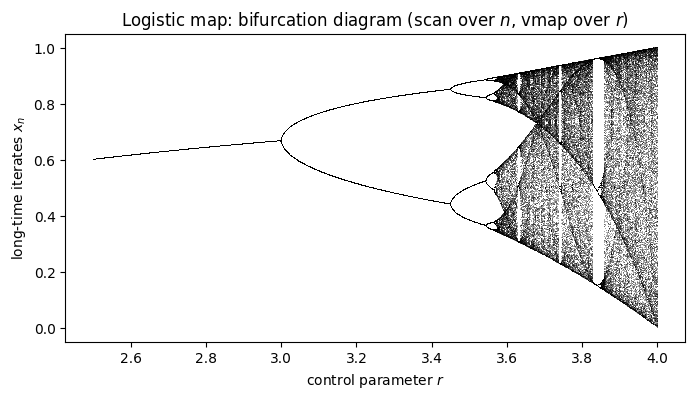

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
tail = np.asarray(orbits[:, -200:])                           # discard the transient, keep the last 200 iterates
ax.plot(np.repeat(np.asarray(rs), 200), tail.reshape(-1), ",", color="k", alpha=0.35)
ax.set_xlabel("control parameter $r$")
ax.set_ylabel("long-time iterates $x_n$")
ax.set_title("Logistic map: bifurcation diagram (scan over $n$, vmap over $r$)")
plt.show()

The familiar bifurcation diagram: a fixed point for $r<3$, period doubling at $r=3$ and $r\approx3.45$, the onset of
chaos at $r\approx3.57$, and periodic windows inside the chaotic region (the large period-3 window near
$r\approx3.83$). The $1.2$ million sequential map iterations run as one compiled program, *scan inside vmap inside
jit*; the printed time includes the compilation.

### 7.2 A simple ODE integrator
An ordinary differential equation $\dot y = f(y,t)$ is solved numerically by stepping in time. Two classic
explicit schemes with step $\Delta t$:

* **Euler**: $y_{n+1} = y_n + \Delta t\, f(y_n,t_n)$ — local error $O(\Delta t^2)$, global error $O(\Delta t)$.
* **Runge–Kutta 4 (RK4)**: four evaluations of $f$ per step,

  $$k_1 = f(y_n,t_n),\quad k_2 = f(y_n+\tfrac{\Delta t}{2}k_1,t_n+\tfrac{\Delta t}{2}),\quad
    k_3 = f(y_n+\tfrac{\Delta t}{2}k_2,t_n+\tfrac{\Delta t}{2}),\quad k_4 = f(y_n+\Delta t\,k_3,t_n+\Delta t),$$

  $$y_{n+1} = y_n + \tfrac{\Delta t}{6}(k_1+2k_2+2k_3+k_4),$$

  constructed so that the Taylor expansion of the exact solution is matched up to $\Delta t^4$: local error
  $O(\Delta t^5)$, global error $O(\Delta t^4)$ (quoted without proof; see Press *et al.* in the references).

"Global error $O(\Delta t^p)$" means: halving the step reduces the error at a fixed final time by $2^p$.
We implement a generic integrator — the carry is the pair $(y, t)$ — and test it on the harmonic oscillator
$\dot q = p,\ \dot p = -q$ with the exact solution $q(t)=\cos t$, $p(t) = -\sin t$ for $q(0)=1, p(0)=0$.

In [24]:
# ==============================================================================
# Generic fixed-step ODE integrator built on lax.scan
# ==============================================================================
def euler_step(f, y, t, dt):
    """One explicit Euler step  y + dt f(y,t)."""
    return y + dt * f(y, t)


def rk4_step(f, y, t, dt):
    """One classical Runge-Kutta-4 step for dy/dt = f(y, t).

    MATH   y_{n+1} = y_n + dt/6 (k1 + 2 k2 + 2 k3 + k4)   with the four slopes k_i defined in the text.
    COST   4 evaluations of f per step; global error O(dt^4).
    """
    k1 = f(y, t)
    k2 = f(y + 0.5 * dt * k1, t + 0.5 * dt)
    k3 = f(y + 0.5 * dt * k2, t + 0.5 * dt)
    k4 = f(y + dt * k3, t + dt)
    return y + dt / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)


def integrate(f, y0, dt, n_steps, stepper=rk4_step):
    """Integrate dy/dt = f(y,t) from t=0 with n_steps steps of size dt; return the trajectory (n_steps, ...).

    JAX   lax.scan with carry (y, t).  `f`, `n_steps` and `stepper` are static structure; y0 and dt are traced.
    """
    def step(carry, _):
        y, t = carry
        y_new = stepper(f, y, t, dt)
        return (y_new, t + dt), y_new

    t0 = jnp.zeros((), dtype=y0.real.dtype)
    _, ys = lax.scan(step, (y0, t0), None, length=n_steps)
    return ys


def oscillator(y, t):
    """Harmonic oscillator, y = (q, p):  dq/dt = p,  dp/dt = -q."""
    return jnp.array([y[1], -y[0]])


y0 = jnp.array([1.0, 0.0], dtype=RDTYPE)
T_final = 20.0
print(" n_steps      dt     Euler error     RK4 error")
for n_steps in (200, 400, 800):
    dt = T_final / n_steps
    exact = jnp.array([jnp.cos(T_final), -jnp.sin(T_final)])
    e_euler = jnp.linalg.norm(integrate(oscillator, y0, dt, n_steps, euler_step)[-1] - exact)
    e_rk4 = jnp.linalg.norm(integrate(oscillator, y0, dt, n_steps, rk4_step)[-1] - exact)
    print(f"{n_steps:8d}  {dt:6.3f}   {float(e_euler):12.3e}  {float(e_rk4):12.3e}")

 n_steps      dt     Euler error     RK4 error


     200   0.100      1.708e+00     1.667e-05


     400   0.050      6.480e-01     1.042e-06


     800   0.025      2.840e-01     6.510e-08


Halving $\Delta t$ reduces the RK4 error by a factor $\approx 16=2^4$ (order 4), and the Euler error by a factor
between $2$ and $3$: Euler is order 1, but at these step sizes it is not yet in its asymptotic regime — its error
is of the order of the solution itself. The reason is that Euler systematically *pumps energy* into the
oscillator. One step maps $(q,p)\mapsto(q+\Delta t\,p,\;p-\Delta t\,q)$, and therefore

$$ q_{n+1}^2+p_{n+1}^2 = (1+\Delta t^2)\,\big(q_n^2+p_n^2\big) $$

*exactly*. After $n=T/\Delta t$ steps the amplitude is multiplied by $(1+\Delta t^2)^{n/2}\approx e^{T\Delta t/2}$,
so the error at the final time is about $(1+\Delta t^2)^{n/2}-1=1.705$, $0.648$ and $0.284$ for the three rows of
the table. The printed errors are larger by at most $0.003$, the contribution of Euler's phase error. Only once
$T\Delta t\ll1$ does $e^{T\Delta t/2}-1\approx T\Delta t/2$ behave like the $O(\Delta t)$ the theory promises. We come back to such structural failures of generic
integrators — and to the unitary methods that avoid them — in
[04 — time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb).

### 7.3 Compile time of an unrolled Python loop and of `scan`
Both versions below compute the same number. The Python loop is unrolled into `n` copies of the body; `scan`
compiles the body once.

In [25]:
# ==============================================================================
# Compile time: unrolled Python loop vs lax.scan
# ==============================================================================
def iterate_unrolled(x, n):
    for _ in range(n):                                        # unrolled at trace time: n copies of the body
        x = 3.7 * x * (1.0 - x)
    return x


def iterate_scan(x, n):
    return lax.scan(lambda c, _: (3.7 * c * (1.0 - c), None), x, None, length=n)[0]


x0 = jnp.asarray(0.3, dtype=RDTYPE)
print("     n   first call, unrolled loop   first call, scan     same result?")
for n in (10, 100, 1000):
    timings = []
    for fn in (iterate_unrolled, iterate_scan):
        compiled = jax.jit(fn, static_argnums=1)              # fresh jit -> nothing cached
        t0 = time.perf_counter()
        out = compiled(x0, n).block_until_ready()
        timings.append((time.perf_counter() - t0, float(out)))
    same = timings[0][1] == timings[1][1]                     # same operations in the same order -> identical bits
    print(f"{n:6d}   {timings[0][0]:18.3f} s   {timings[1][0]:16.3f} s     {same}")

     n   first call, unrolled loop   first call, scan     same result?


    10                0.176 s              0.179 s     True


   100                0.393 s              0.094 s     True


  1000                2.936 s              0.124 s     True


The first-call time of `scan` does not depend on $n$. The unrolled program has $n$ copies of the body, and at
$n=1000$ its compilation takes many times longer than that of `scan` (at small $n$ the fixed cost of any
compilation dominates both columns). With the $10^4$–$10^5$ steps of a realistic time evolution the unrolled version
becomes unusable. Both versions return the same bits, because they perform the same operations in the same order;
for this chaotic map a single round-off difference would grow to order one within about a hundred steps.

> **JAX practice.** Short loops over *structure* (over the ten spins of a chain, over the gates of a circuit layer)
> may stay Python loops — unrolling them lets the compiler fuse everything. Long loops over *time* or *iterations*
> belong in `lax.scan` (fixed number of steps) or `lax.while_loop` (data-dependent stopping condition;
> not differentiable in reverse mode). `lax.fori_loop` is a convenience wrapper for "scan without outputs".

> **Common pitfall.** `scan` insists that the carry keeps both its shape and its dtype. Starting the carry as an
> `int32` (or `float32`) array and adding a `float64` inside the body produces the error *"scan body function carry
> input and carry output must have equal types"*; so does a carry whose shape grows from step to step. Create the
> initial carry with the final dtype: `jnp.zeros((), dtype=RDTYPE)`. (A bare Python `0` happens to survive, because
> it is only *weakly* typed and `scan` re-traces the body until the carry type settles — do not rely on it.)

## 8. Branching inside compiled code: `jnp.where`, `lax.cond`, `lax.switch`

We met `TracerBoolConversionError` in Section 5.4. The compiled-code replacements for `if`/`else` are:

| construct | semantics | use when |
|---|---|---|
| `jnp.where(c, a, b)` | element-wise: take `a` where `c` is true, else `b`; **both** `a` and `b` are computed | cheap alternatives, array-valued conditions |
| `lax.cond(c, f_true, f_false, *operands)` | scalar condition; only one branch is *executed* (both are *compiled*) | expensive branches |
| `lax.switch(i, [f0, f1, ...], *operands)` | integer-indexed choice between several branches | e.g. "apply the $i$-th operator" |

Both branches of `lax.cond` must return results of identical shape and dtype — the compiled program needs a fixed
output type. A physics-flavoured example: a laser pulse that is switched on only for $0\le t< T_{\rm pulse}$.

In [26]:
# ==============================================================================
# A square pulse, three ways
# ==============================================================================
def pulse_where(t, omega0, t_pulse):
    """Omega(t) = omega0 for 0 <= t < t_pulse, else 0   -- element-wise selection."""
    return jnp.where((t >= 0) & (t < t_pulse), omega0, 0.0)


def pulse_cond(t, omega0, t_pulse):
    """Same function with lax.cond (scalar t only): exactly one branch runs."""
    return lax.cond((t >= 0) & (t < t_pulse), lambda: omega0, lambda: jnp.zeros_like(omega0))


ts = jnp.linspace(-1.0, 3.0, 9, dtype=RDTYPE)
omega0 = jnp.asarray(2.0, dtype=RDTYPE)
print("t          :", ts)
print("where      :", jax.jit(pulse_where)(ts, omega0, 2.0))                       # works on whole arrays
print("vmap(cond) :", jax.jit(jax.vmap(pulse_cond, in_axes=(0, None, None)))(ts, omega0, 2.0))

# Python `if` is perfectly fine for STATIC information such as shapes:
@jax.jit
def normalise(v):
    if v.ndim != 1:                                            # v.ndim is known at trace time -> ordinary Python
        raise ValueError("expected a vector")
    return v / jnp.linalg.norm(v)


print("static `if` on the shape is allowed:", normalise(jnp.array([3.0, 4.0], dtype=RDTYPE)))

t          : [-1.  -0.5  0.   0.5  1.   1.5  2.   2.5  3. ]


where      : [0. 0. 2. 2. 2. 2. 0. 0. 0.]


vmap(cond) : [0. 0. 2. 2. 2. 2. 0. 0. 0.]


static `if` on the shape is allowed: [0.6 0.8]


Both constructions give the same pulse. Note `&` instead of `and`: Python's `and` would again try to convert a
tracer to a `bool`. Under `vmap`, a `lax.cond` is automatically converted into a `where`-like selection, because
different samples of the batch may need different branches.

> **JAX practice.** Conditions on *shapes, dtypes, static arguments and Python constants* are ordinary Python and
> are resolved at trace time. Only conditions on *array values* need `where`/`cond`. In the measurement notebook
> ([08](../ch03_matrix_free_engine/08_measurements.ipynb)) a random measurement outcome decides which projector is applied — with
> `jnp.where`, so that thousands of measurement shots can be `vmap`-ed.

## 9. `jax.grad` — exact derivatives of programs

### 9.1 Three ways to differentiate
* **By hand / symbolically**: exact, but laborious and error-prone for long programs.
* **Finite differences**: $f'(x)\approx[f(x+h)-f(x-h)]/2h$. Easy, but approximate (see 9.2) and expensive: a
  function of $n$ parameters needs $2n$ evaluations for one gradient.
* **Automatic differentiation (AD)**: every program is a composition of elementary operations whose derivatives
  are known; the chain rule is applied *mechanically, operation by operation, to the traced program*
  (see the survey by Baydin *et al.*, J. Mach. Learn. Res. **18**(153), 1 (2018)). The result is
  exact to round-off. In *reverse mode* — the mode used by `jax.grad`, identical to "back-propagation" — the
  gradient of a scalar function with respect to **all** $n$ inputs costs only a small multiple (typically 2–4) of
  one function evaluation, *independently of $n$*. The price is memory: intermediate results of the forward pass
  must be stored for the backward pass.

`jax.grad(f)` is again a function transformation: it takes $f:\mathbb{R}^n\to\mathbb{R}$ and returns the function
$\nabla f$. It can be applied repeatedly (second derivatives) and combined with `jit` and `vmap`.

In [27]:
# ==============================================================================
# grad: first and second derivative of a scalar function, checked against the analytic result
# ==============================================================================
def f(x):
    """f(x) = exp(-x^2) sin(3x)"""
    return jnp.exp(-x**2) * jnp.sin(3 * x)


def df_exact(x):
    """f'(x) = exp(-x^2) [3 cos(3x) - 2x sin(3x)]   (product rule)"""
    return jnp.exp(-x**2) * (3 * jnp.cos(3 * x) - 2 * x * jnp.sin(3 * x))


df = jax.grad(f)                       # a new FUNCTION: x -> f'(x)
d2f = jax.grad(jax.grad(f))            # transformations compose: x -> f''(x)

x0 = jnp.asarray(0.7, dtype=RDTYPE)
print(f"f'(0.7)   AD     = {float(df(x0)):+.14f}")
print(f"f'(0.7)   exact  = {float(df_exact(x0)):+.14f}")
print(f"f''(0.7)  AD     = {float(d2f(x0)):+.14f}   (= derivative of the exact f': {float(jax.grad(df_exact)(x0)):+.14f})")
assert abs(df(x0) - df_exact(x0)) < TOL

f'(0.7)   AD     = -1.66820092444002


f'(0.7)   exact  = -1.66820092444002


f''(0.7)  AD     = -2.18260736021138   (= derivative of the exact f': -2.18260736021138)


### 9.2 Finite differences: truncation error and round-off error
Taylor expansion gives the *truncation* errors

$$\frac{f(x+h)-f(x)}{h} = f'(x) + \tfrac{h}{2}f''(x)+\dots,\qquad
  \frac{f(x+h)-f(x-h)}{2h} = f'(x) + \tfrac{h^2}{6}f'''(x)+\dots$$

so one is tempted to take $h$ tiny. But $f$ is only known to relative precision $\epsilon$ (machine epsilon), and
the subtraction $f(x+h)-f(x-h)$ cancels the leading digits: the *round-off* error of the quotient is
$\sim\epsilon|f|/h$ and **grows** as $h\to0$. The total error is minimal at $h\sim\epsilon^{1/2}$ (forward) or
$h\sim\epsilon^{1/3}$ (central), up to prefactors that depend on $f$ and its derivatives, and never reaches machine
precision. We measure this with `vmap` over $h$.

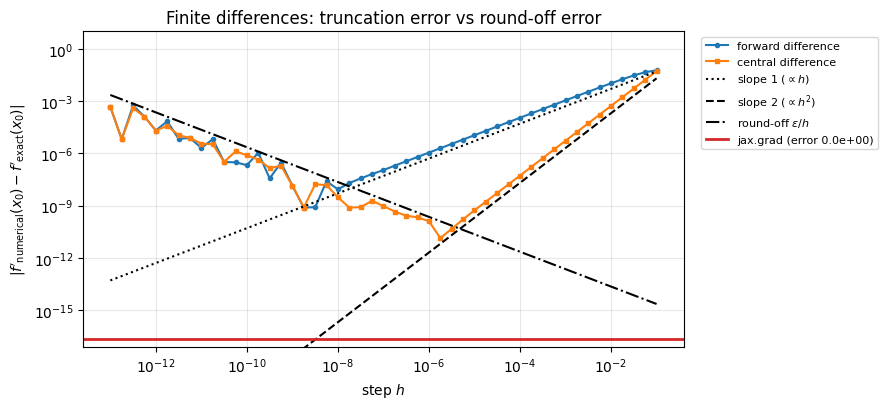

best forward difference : error 7.6e-10 at h = 1.8e-09
best central difference : error 1.3e-11 at h = 1.8e-06
jax.grad                : error 0.0e+00


In [28]:
# ==============================================================================
# Error of finite-difference derivatives versus step h  (vmap over h)
# ==============================================================================
hs = jnp.logspace(-13, -1, 49, dtype=RDTYPE)
forward = jax.vmap(lambda h: (f(x0 + h) - f(x0)) / h)(hs)
central = jax.vmap(lambda h: (f(x0 + h) - f(x0 - h)) / (2 * h))(hs)
err_fwd = np.abs(np.asarray(forward - df_exact(x0)))
err_cen = np.abs(np.asarray(central - df_exact(x0)))
err_ad = abs(float(df(x0) - df_exact(x0)))
eps = float(jnp.finfo(RDTYPE).eps)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.loglog(hs, err_fwd, "o-", ms=3, label="forward difference")
ax.loglog(hs, err_cen, "s-", ms=3, label="central difference")
ax.loglog(hs, 0.5 * np.asarray(hs), "k:", label=r"slope 1 ($\propto h$)")
ax.loglog(hs, 2.0 * np.asarray(hs) ** 2, "k--", label=r"slope 2 ($\propto h^2$)")
ax.loglog(hs, eps / np.asarray(hs), "k-.", label=r"round-off $\epsilon/h$")
ax.axhline(max(err_ad, eps / 10), color="C3", lw=2, label=f"jax.grad (error {err_ad:.1e})")
ax.set_xlabel("step $h$")
ax.set_ylabel(r"$|f'_{\rm numerical}(x_0) - f'_{\rm exact}(x_0)|$")
ax.set_title("Finite differences: truncation error vs round-off error")
ax.set_ylim(eps / 30, 10)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"best forward difference : error {err_fwd.min():.1e} at h = {float(hs[err_fwd.argmin()]):.1e}")
print(f"best central difference : error {err_cen.min():.1e} at h = {float(hs[err_cen.argmin()]):.1e}")
print(f"jax.grad                : error {err_ad:.1e}")

The V-shaped curves show the two regimes: to the right the truncation error with the predicted slopes 1 and 2, to
the left the round-off error $\propto\epsilon/h$. The best finite-difference results sit at the bottom of the V —
several orders of magnitude above the AD result, which is exact to machine precision (the red line is drawn at
$\epsilon/10$ if the AD error is exactly zero). The measured optimal steps lie a factor $3$–$10$ below
$\epsilon^{1/2}=1.5\times10^{-8}$ and $\epsilon^{1/3}=6\times10^{-6}$: the round-off branch is noisy, and the grid
has only four points per decade. Finite differences remain useful as an **independent check of a gradient code**,
with $h$ chosen near the bottom of the V.

### 9.3 The rules of `grad`
`grad` differentiates with respect to the **first** argument by default (`argnums` changes that), the function must
return a **real scalar**, and the differentiated input must be a **float** array. Each violation has its own
message:

In [29]:
# ==============================================================================
# Three typical grad errors
# ==============================================================================
show_error(jax.grad(lambda v: v**2), jnp.arange(3.0))                         # output is a vector, not a scalar
show_error(jax.grad(lambda v: jnp.sum(v**2)), jnp.arange(3))                  # integer input
show_error(jax.grad(lambda v: jnp.sum(jnp.exp(1j * v))), jnp.arange(3.0))     # complex output

TypeError: Gradient only defined for scalar-output functions. Output had shape: (3,).
TypeError: grad requires real- or complex-valued inputs (input dtype that is a sub-dtype of np.inexact), but got int64. If you want to use Boolean- or integer-valued inputs, use vjp or set allow_int to True.


TypeError: grad requires real-valued outputs (output dtype that is a sub-dtype of np.floating), but got complex128. For holomorphic differentiation, pass holomorphic=True. For differentiation of non-holomorphic functions involving complex outputs, use jax.vjp directly.


In physics the cost function is practically always real (an energy, a fidelity, a squared residual), even when the
intermediate quantities — the wave functions themselves — are complex. That is fine: `grad` happily differentiates *through*
complex arithmetic as long as the final output is real. (For vector-valued functions use `jax.jacobian`; for
second derivatives of multivariate functions `jax.hessian`.)

> **Common pitfall — `nan` gradients from `jnp.where`.** Since `where` evaluates *both* branches, the unselected
> branch also takes part in the chain rule, multiplied by zero — and $0\cdot\infty$ is `nan`. Example:
> `jnp.where(x > 0, jnp.sqrt(x), 0.0)` has the correct value $0$ at $x=0$ but the gradient `nan`, because the
> derivative of `sqrt` at $0$ is infinite. The cure is the "double where": make the *input* of the dangerous
> function safe as well, `jnp.sqrt(jnp.where(x > 0, x, 1.0))`.

In [30]:
unsafe = lambda x: jnp.where(x > 0, jnp.sqrt(x), 0.0)
safe = lambda x: jnp.where(x > 0, jnp.sqrt(jnp.where(x > 0, x, 1.0)), 0.0)
zero = jnp.zeros((), dtype=RDTYPE)
print("gradient at x=0, naive where :", jax.grad(unsafe)(zero))
print("gradient at x=0, double where:", jax.grad(safe)(zero))

gradient at x=0, naive where : nan
gradient at x=0, double where: 0.0


### 9.4 Minimising a function: the ground state of one spin by gradient descent
This is a *variational* calculation in its simplest form (the subject of Chapter 11, variational quantum circuits).
Take one spin with the Hamiltonian

$$H = \tfrac{\Delta}{2}\sigma_z + \tfrac{\Omega}{2}\sigma_x .$$

Since $H = \tfrac12(\Omega,0,\Delta)\cdot\vec\sigma$ and $(\vec n\cdot\vec\sigma)^2=1$ for a unit vector $\vec n$,
we have $H^2=\tfrac14(\Omega^2+\Delta^2)\,\mathbb{1}$, so the eigenvalues are $\pm\tfrac12\sqrt{\Omega^2+\Delta^2}$.
The variational principle says that for *any* normalised state $E(\theta,\varphi) =
\langle\theta,\varphi|H|\theta,\varphi\rangle \ge E_0$, with equality for the ground state. Every spin-1/2 state is
of the form $|\theta,\varphi\rangle$, so minimising $E$ over the two angles must give exactly
$E_0=-\tfrac12\sqrt{\Omega^2+\Delta^2}$.

*Gradient descent* is the simplest minimiser: repeat $\;p \leftarrow p - \eta\,\nabla E(p)\;$ with a learning rate
$\eta$. `jax.value_and_grad` returns $E$ and $\nabla E$ from one forward and one backward pass; the iteration is a
`lax.scan` whose carry is the parameter vector.

gradient descent : E = -0.610327780787   at theta = 2.181522, phi = 3.141593
analytic         : E0 = -0.610327780787   (-sqrt(Omega^2 + Delta^2)/2)
jnp.linalg.eigvalsh: E0 = -0.610327780787
expected angles  : theta = pi - arctan(Omega/Delta) = 2.181522, phi = pi = 3.141593
Bloch vector     : [-0.819232  0.       -0.573462]   prediction -n = [-0.819232 -0.       -0.573462]


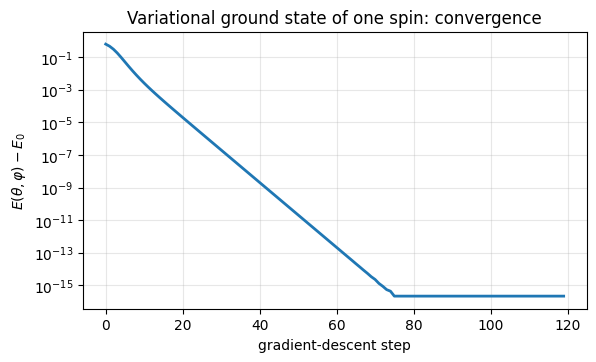

In [31]:
# ==============================================================================
# PARAMETERS
# ==============================================================================
OMEGA, DELTA = 1.0, 0.7          # Rabi frequency and detuning (units: hbar = 1)
ETA = 0.5                        # learning rate of gradient descent
N_GD = 120                       # number of gradient-descent steps

# ==============================================================================
# Variational ground state of H = (DELTA/2) sigma_z + (OMEGA/2) sigma_x
# ==============================================================================
H_spin = 0.5 * DELTA * sigma_z + 0.5 * OMEGA * sigma_x


def variational_energy(params):
    """E(theta, phi) = <theta,phi| H |theta,phi>;  params = array([theta, phi])."""
    return expectation(bloch_state(params[0], params[1]), H_spin)


@jax.jit
def gradient_descent(params0):
    """N_GD steps of  p <- p - ETA grad E(p);  returns (final parameters, energy history)."""
    def step(p, _):
        e, g = jax.value_and_grad(variational_energy)(p)      # energy AND gradient in one go
        return p - ETA * g, e

    return lax.scan(step, params0, None, length=N_GD)


params_opt, energies = gradient_descent(jnp.array([1.0, 2.0], dtype=RDTYPE))
E0_exact = -0.5 * np.sqrt(OMEGA**2 + DELTA**2)
E0_eigh = float(jnp.linalg.eigvalsh(H_spin)[0])
E_final = float(variational_energy(params_opt))

print(f"gradient descent : E = {E_final:+.12f}   at theta = {float(params_opt[0]):.6f}, phi = {float(params_opt[1]):.6f}")
print(f"analytic         : E0 = {E0_exact:+.12f}   (-sqrt(Omega^2 + Delta^2)/2)")
print(f"jnp.linalg.eigvalsh: E0 = {E0_eigh:+.12f}")
print(f"expected angles  : theta = pi - arctan(Omega/Delta) = {np.pi - np.arctan2(OMEGA, DELTA):.6f}, phi = pi = {np.pi:.6f}")

# Bloch vector (<sigma_x>, <sigma_y>, <sigma_z>) of the optimised state vs the prediction -(Omega, 0, Delta)/Omega_R
psi_opt = bloch_state(params_opt[0], params_opt[1])
bloch_opt = np.array([float(expectation(psi_opt, P)) for P in (sigma_x, sigma_y, sigma_z)])
bloch_pred = -np.array([OMEGA, 0.0, DELTA]) / np.sqrt(OMEGA**2 + DELTA**2)
print("Bloch vector     :", np.round(bloch_opt, 6), "  prediction -n =", np.round(bloch_pred, 6))
assert abs(E_final - E0_exact) < (1e-9 if PRECISION == "double" else 1e-4)
assert np.max(np.abs(bloch_opt - bloch_pred)) < (1e-6 if PRECISION == "double" else 1e-2)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.semilogy(np.maximum(np.asarray(energies) - E0_exact, eps), lw=2)       # clip at machine epsilon for the log axis
ax.set_xlabel("gradient-descent step")
ax.set_ylabel(r"$E(\theta,\varphi) - E_0$")
ax.set_title("Variational ground state of one spin: convergence")
ax.grid(alpha=0.3)
plt.show()

Gradient descent converges to the exact ground-state energy — three independent numbers (variational, analytic,
dense diagonalisation) agree. The excess energy decays exponentially with the iteration number (a straight line
on the logarithmic scale), the generic behaviour of gradient descent near a quadratic minimum, until it hits the
round-off floor (the curve is clipped at machine epsilon). The optimal angles have a simple meaning: the ground
state is the point of the Bloch sphere *anti-parallel* to the "field" direction $(\Omega,0,\Delta)$, i.e.
$\varphi=\pi$ and $\cos\theta=-\Delta/\Omega_R$, which for $\Delta>0$ (our case) reads
$\theta=\pi-\arctan(\Omega/\Delta)$ — the printed Bloch vector confirms it. (The angles themselves
are not unique: $(-\theta,\varphi+\pi)$ describes the same state, and another starting point may converge to that
representation. The Bloch vector, a physical quantity, is the meaningful comparison.)

> **Physics insight.** This is a *variational quantum eigensolver* in miniature: a parametrised state, an energy
> expectation value as cost function, a gradient-based optimiser. In Chapter 11 the state will be an $N$-qubit circuit
> with hundreds of angles — and the code pattern `scan(value_and_grad(energy))` will be the same.

## 10. Random numbers: explicit keys

NumPy's `np.random.rand()` draws from a hidden *global* generator whose state changes with every call. This is
convenient but hostile to everything JAX stands for: the result of a function then depends on how many random
numbers were drawn *before* it was called, i.e. it is not pure; the order of evaluation matters (so the compiler may not
reorder or parallelise), and "sample 17 of the batch" has no well-defined random stream under `vmap`.

JAX makes the generator state **explicit**. A *key* is a small array; a random function is a deterministic,
pure function of the key:

* `key = jax.random.PRNGKey(seed)` creates a key from an integer seed;
* `jax.random.normal(key, shape)` etc. — **same key, same numbers, always**;
* `jax.random.split(key, n)` deterministically produces `n` new, statistically independent keys.

The discipline is: *never use a key twice*. Whenever you need randomness in several places, split.

(In newer code you will also meet `jax.random.key(seed)`, the *typed* key API. It drives the same generator — the
counter-based Threefry algorithm of Salmon *et al.*, see the references — but wraps the two integers in an opaque
scalar of dtype `key<fry>` so that a key can never be mistaken for ordinary data. We keep `PRNGKey` here precisely
because its raw form makes the point "a key is just an array" visible.)

In [32]:
# ==============================================================================
# Keys: same key -> same numbers;  split -> independent streams
# ==============================================================================
key = jax.random.PRNGKey(42)
print("a key is just a small array:", key)
print("same key twice  :", jax.random.normal(key, (3,), dtype=RDTYPE), jax.random.normal(key, (3,), dtype=RDTYPE))

key, sub1, sub2 = jax.random.split(key, 3)                    # idiom: replace `key`, use the sub-keys
print("after splitting :", jax.random.normal(sub1, (3,), dtype=RDTYPE), jax.random.normal(sub2, (3,), dtype=RDTYPE))

a key is just a small array: [ 0 42]


same key twice  : [-0.18471175 -2.16982456  0.18693555] [-0.18471175 -2.16982456  0.18693555]


after splitting : [ 0.64989201  0.11847861 -1.55571939] [-0.32162797  0.42463557  0.85070082]


> **Common pitfall.** Re-using a key is not an error that JAX can detect — you silently get *identical* "random"
> numbers in two places (e.g. identical noise on two different spins). The idiom `key, sub = jax.random.split(key)`
> at every use protects you.

### 10.1 Monte-Carlo estimate of $\pi$, with error bars from `vmap`
Draw $n$ points uniformly in the unit square; the fraction that falls inside the quarter disc $x^2+y^2<1$ estimates
$\pi/4$. Each point is a Bernoulli trial with success probability $p=\pi/4$, so the estimator
$\hat\pi = 4\,n_{\rm in}/n$ has the standard deviation

$$\sigma_{\hat\pi} = 4\sqrt{\frac{p(1-p)}{n}} = \sqrt{\frac{\pi(4-\pi)}{n}} \approx \frac{1.64}{\sqrt n}. $$

This $1/\sqrt{n}$ law governs every sampling method of this course (measurement shots, quantum trajectories,
classical shadows). To *measure* the statistical error we repeat the whole estimate for 200 independent keys — a
`vmap` over keys.

n =     100:  mean of 200 estimates = 3.15600   scatter (std) = 0.15768   theory sqrt(pi(4-pi)/n) = 0.16422


n =    1000:  mean of 200 estimates = 3.14156   scatter (std) = 0.05369   theory sqrt(pi(4-pi)/n) = 0.05193


n =   10000:  mean of 200 estimates = 3.14027   scatter (std) = 0.01622   theory sqrt(pi(4-pi)/n) = 0.01642


n =  100000:  mean of 200 estimates = 3.14099   scatter (std) = 0.00515   theory sqrt(pi(4-pi)/n) = 0.00519


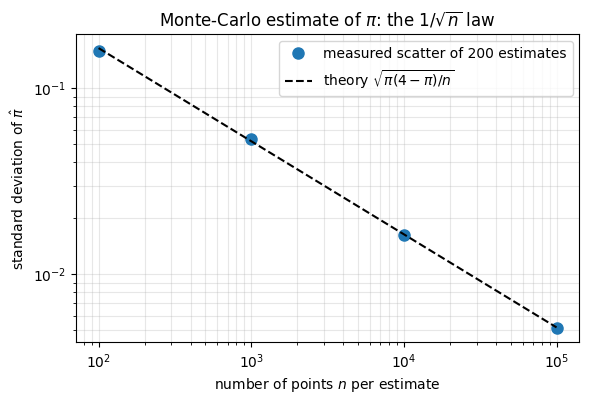

measured / predicted scatter: [0.96  1.034 0.988 0.991] | against the misread sqrt(p(1-p)/n): [3.84 4.14 3.95 3.96]


In [33]:
# ==============================================================================
# Monte-Carlo pi: one estimate = pure function of a key;  vmap over keys = independent repetitions
# ==============================================================================
def estimate_pi(key, n_points):
    """4 * (fraction of n_points uniform points in the unit square that fall inside the quarter disc)."""
    xy = jax.random.uniform(key, (n_points, 2), dtype=RDTYPE)
    inside = jnp.sum(xy**2, axis=1) < 1.0
    return 4.0 * jnp.mean(inside)


N_REPEAT = 200
keys = jax.random.split(jax.random.PRNGKey(2024), N_REPEAT)            # 200 independent keys
many_estimates = jax.jit(jax.vmap(estimate_pi, in_axes=(0, None)), static_argnums=1)

ns = [100, 1_000, 10_000, 100_000]
stds, means = [], []
for n in ns:
    est = many_estimates(keys, n)                                      # shape (200,)
    means.append(float(jnp.mean(est)))
    stds.append(float(jnp.std(est)))
    print(f"n = {n:7d}:  mean of 200 estimates = {means[-1]:.5f}   scatter (std) = {stds[-1]:.5f}"
          f"   theory sqrt(pi(4-pi)/n) = {np.sqrt(np.pi * (4 - np.pi) / n):.5f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(ns, stds, "o", ms=8, label="measured scatter of 200 estimates")
ax.loglog(ns, np.sqrt(np.pi * (4 - np.pi) / np.array(ns)), "k--", label=r"theory $\sqrt{\pi(4-\pi)/n}$")
ax.set_xlabel("number of points $n$ per estimate")
ax.set_ylabel(r"standard deviation of $\hat\pi$")
ax.set_title(r"Monte-Carlo estimate of $\pi$: the $1/\sqrt{n}$ law")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

# CHECKPOINT: the measured scatter agrees with the binomial prediction within 15 %  (200 repetitions -> ~5 % noise).
# Wrong control: sqrt(p(1-p)/n) is the scatter of the FRACTION n_in/n; forgetting the factor 4 must fail the same test.
ratio = np.array(stds) / np.sqrt(np.pi * (4 - np.pi) / np.array(ns))
ratio_wrong = np.array(stds) / np.sqrt(np.pi / 4 * (1 - np.pi / 4) / np.array(ns))
print("measured / predicted scatter:", np.round(ratio, 3), "| against the misread sqrt(p(1-p)/n):", np.round(ratio_wrong, 2))
assert np.all(np.abs(ratio - 1) < 0.15) and np.all(np.abs(ratio_wrong - 1) > 0.15), ratio

The measured scatter follows the prediction $1.64/\sqrt n$ over three decades: **one more digit costs a hundred
times more samples**. (The standard deviation estimated from 200 repetitions itself fluctuates by about
$1/\sqrt{2\cdot200}=5\,\%$; the printed ratios deviate from $1$ by at most $4\,\%$.) The same test rejects the
scatter $\sqrt{p(1-p)/n}$ of the fraction $n_{\rm in}/n$, which lacks the factor $4$ of $\hat\pi=4n_{\rm in}/n$.
Because the keys are fixed, re-running the notebook reproduces every digit.

## 11. Pytrees

Real programs do not pass around single arrays but *structures*: a dictionary of model parameters, a tuple
`(state, time)`, a list of matrices. JAX calls any nested combination of tuples, lists and dicts whose leaves are
arrays a **pytree**, and every transformation accepts pytrees wherever it accepts arrays: `grad` of a function of a
dict returns a dict of gradients with the same keys, the carry of `scan` may be a tuple (we used `(y, t)` above),
`vmap` batches every leaf, `jax.block_until_ready` waits for every leaf. The utility `jax.tree.map(fn, tree, ...)`
applies `fn` leaf by leaf — a gradient-descent update of all parameters is a one-liner.

In [34]:
# ==============================================================================
# Pytrees: gradients with respect to a dictionary of parameters
# ==============================================================================
def lorentzian_model(params, x):
    """A Lorentzian line  amp * gamma^2 / ((x - x0)^2 + gamma^2)  with parameters stored in a dict."""
    return params["amp"] * params["gamma"] ** 2 / ((x - params["x0"]) ** 2 + params["gamma"] ** 2)


params = {"amp": jnp.asarray(2.0, RDTYPE), "x0": jnp.asarray(0.5, RDTYPE), "gamma": jnp.asarray(0.3, RDTYPE)}
grads = jax.grad(lorentzian_model)(params, 0.8)               # differentiate w.r.t. the first argument: the dict
print("gradient pytree :", {k: round(float(v), 6) for k, v in grads.items()})

updated = jax.tree.map(lambda p, g: p - 0.01 * g, params, grads)   # one gradient-descent step on every leaf
print("updated params  :", {k: round(float(v), 6) for k, v in updated.items()})

gradient pytree : {'amp': 0.5, 'gamma': 3.333333, 'x0': 3.333333}
updated params  : {'amp': 1.995, 'gamma': 0.266667, 'x0': 0.466667}


The gradient has the same dictionary structure as the parameters: `grads["x0"]` is $\partial(\text{model})/\partial
x_0$, and so on. We will use exactly this pattern to fit two parameters in the mini-project.

## 12. Composing transformations

`jit`, `vmap` and `grad` all map *functions to functions*, so they can be stacked in any order. Read a composition
from the inside out:

```python
jax.jit(jax.vmap(jax.grad(f)))
#                 └ grad : x -> f'(x)            for ONE scalar x
#        └ vmap : the same for a whole array of x values  (a "per-sample gradient")
# └ jit  : compile the resulting batched derivative program
```

Put `jit` outermost, so that the compiler sees — and fuses — everything. As an example we tabulate the function of
Section 9 together with its first and second derivative on a grid, without writing a single derivative by hand.

max |AD derivative - analytic derivative| on the grid: 4.440892098500626e-16


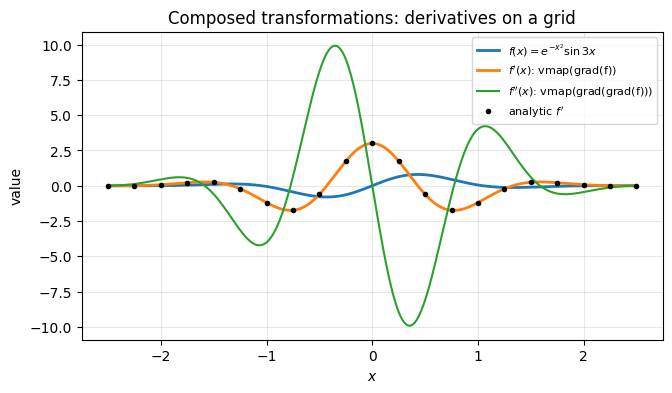

In [35]:
# ==============================================================================
# jit(vmap(grad(f))): derivatives on a whole grid
# ==============================================================================
xs = jnp.linspace(-2.5, 2.5, 401, dtype=RDTYPE)
f_grid = jax.jit(jax.vmap(f))(xs)
df_grid = jax.jit(jax.vmap(jax.grad(f)))(xs)
d2f_grid = jax.jit(jax.vmap(jax.grad(jax.grad(f))))(xs)

err = float(jnp.max(jnp.abs(df_grid - df_exact(xs))))
print("max |AD derivative - analytic derivative| on the grid:", err)
assert err < TOL * 10

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(xs, f_grid, lw=2, label=r"$f(x)=e^{-x^2}\sin 3x$")
ax.plot(xs, df_grid, lw=2, label=r"$f'(x)$: vmap(grad(f))")
ax.plot(xs, d2f_grid, lw=1.5, label=r"$f''(x)$: vmap(grad(grad(f)))")
ax.plot(xs[::20], df_exact(xs[::20]), "k.", label=r"analytic $f'$")
ax.set_xlabel("$x$")
ax.set_ylabel("value")
ax.set_title("Composed transformations: derivatives on a grid")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

The dots (analytic $f'$) lie on the `vmap(grad(f))` curve, and the zeros of $f'$ coincide with the extrema of $f$,
the zeros of $f''$ with its inflection points, as they must. We are now equipped for a small but complete physics
project that uses **all** the tools of this notebook together.

## 13. Mini-project: Rabi oscillations of a two-level atom

### 13.1 The physics
An atom (or a superconducting qubit, a trapped ion, a spin in a magnetic field, …) has two relevant levels, the
ground state $|g\rangle$ and the excited state $|e\rangle$, separated by the energy $\hbar\omega_0$. It is driven by
a nearly resonant oscillating field (a laser, a microwave) of frequency $\omega$. Two parameters matter:

* the **Rabi frequency** $\Omega$ — the strength of the atom–field coupling, $\Omega = d\,\mathcal{E}_0/\hbar$
  (dipole matrix element times field amplitude, divided by $\hbar$);
* the **detuning** $\Delta=\omega-\omega_0$ — how far the drive is from resonance.

In the frame rotating with the drive, and after the *rotating-wave approximation* (dropping terms that oscillate at
the very high frequency $2\omega$; we quote this standard result, see Foot, *Atomic Physics*, Chapter 7), the
Hamiltonian becomes **time independent**. With $\hbar=1$, the identification $|g\rangle=|0\rangle=(1,0)^T$,
$|e\rangle=|1\rangle=(0,1)^T$, and the constant energy offset removed, it reads

$$ H = \frac{\Delta}{2}\,\sigma_z + \frac{\Omega}{2}\,\sigma_x
     = \frac12\begin{pmatrix}\Delta & \Omega\\ \Omega & -\Delta\end{pmatrix}. \qquad\text{(1)}$$

(Check: $|e\rangle$ has the energy $-\Delta/2$ and $|g\rangle$ has $+\Delta/2$; in the rotating frame the excited
state lies $\omega_0-\omega=-\Delta$ above the ground state.) This is the same Hamiltonian as in Section 9.4.

**The Rabi formula.** Write $H=\tfrac{\Omega_R}{2}\,\vec n\cdot\vec\sigma$ with the *generalised Rabi frequency*
$\Omega_R=\sqrt{\Omega^2+\Delta^2}$ and the unit vector $\vec n=(\Omega,0,\Delta)/\Omega_R$. Because
$(\vec n\cdot\vec\sigma)^2=\mathbb 1$, the exponential series splits into its even and odd part,

$$ U(t)=e^{-iHt}=\sum_k \frac{(-i\Omega_R t/2)^k}{k!}(\vec n\cdot\vec\sigma)^k
      =\cos\frac{\Omega_R t}{2}\,\mathbb 1 - i\sin\frac{\Omega_R t}{2}\;\vec n\cdot\vec\sigma. \qquad\text{(2)}$$

Starting in the ground state, the probability to find the atom excited is
$P_e(t)=|\langle e|U(t)|g\rangle|^2$. Only $\sigma_x$ connects $|g\rangle$ and $|e\rangle$, with matrix element
$n_x=\Omega/\Omega_R$, hence

$$ P_e(t) = \frac{\Omega^2}{\Omega^2+\Delta^2}\,\sin^2\!\Big(\frac{\sqrt{\Omega^2+\Delta^2}}{2}\,t\Big).\qquad\text{(3)}$$

On resonance ($\Delta=0$) the population swings completely between $|g\rangle$ and $|e\rangle$ with frequency
$\Omega$; a pulse of duration $t_\pi=\pi/\Omega$ (a "$\pi$ pulse") inverts the atom — the basic single-qubit gate
of every quantum computer. Off resonance the oscillation becomes *faster* ($\Omega_R>\Omega$) and *incomplete*
(amplitude $\Omega^2/\Omega_R^2<1$). Rabi computed these transition probabilities in 1937 for a magnetic moment in
a magnetic field rotating about an inclined axis (Phys. Rev. **51**, 652 (1937)); Griffiths and Schroeter treat spin 1/2
in Chapter 4 and driven two-level systems in Chapter 11.

Eq. (3) is our **analytic reference**. We now pretend not to know it and solve the Schrödinger equation
numerically.

### 13.2 From formula to code: Schrödinger equation + RK4 + scan
The Schrödinger equation $i\,\partial_t|\psi\rangle=H|\psi\rangle$ is an ODE $\dot y=f(y,t)$ for the complex vector
$y=\psi\in\mathbb C^2$ with $f(\psi,t)=-iH\psi$. We can therefore reuse `integrate` and `rk4_step` from Section 7.2
*unchanged* — they never assumed real numbers. At every step we record $P_e=|\psi_1|^2$ and the norm
$\langle\psi|\psi\rangle$, which the exact evolution conserves.

In [36]:
# ==============================================================================
# PARAMETERS of the mini-project  (time in units of 1/OMEGA_TRUE, hbar = 1)
# ==============================================================================
OMEGA_TRUE = 1.0                 # Rabi frequency
DELTA_TRUE = 0.5                 # detuning
T_MAX = 20.0                     # total evolution time
N_STEPS = 400                    # RK4 steps  ->  dt = 0.05

# ==============================================================================
# STEP 1: Hamiltonian, analytic reference, numerical solution
# ==============================================================================
def rabi_hamiltonian(omega, delta):
    """H = (delta/2) sigma_z + (omega/2) sigma_x   -- Eq. (1); omega, delta may be traced scalars."""
    return 0.5 * delta * sigma_z + 0.5 * omega * sigma_x


def p_excited_exact(t, omega, delta):
    """Rabi formula, Eq. (3):  P_e(t) = omega^2/Omega_R^2 * sin^2(Omega_R t/2),  Omega_R = sqrt(omega^2+delta^2)."""
    omega_r = jnp.sqrt(omega**2 + delta**2)
    return omega**2 / omega_r**2 * jnp.sin(0.5 * omega_r * t) ** 2


def psi_exact(t, omega, delta):
    """Exact state U(t)|g> from Eq. (2):  ( cos(a) - i n_z sin(a),  -i n_x sin(a) ),  a = Omega_R t/2."""
    omega_r = jnp.sqrt(omega**2 + delta**2)
    a = 0.5 * omega_r * t
    return jnp.array([jnp.cos(a) - 1j * (delta / omega_r) * jnp.sin(a), -1j * (omega / omega_r) * jnp.sin(a)], dtype=CDTYPE)


def rabi_trajectory(omega, delta, dt, n_steps):
    """Integrate i dpsi/dt = H psi from |g> = (1,0) with RK4; return psi(t_n) for t_n = dt, 2dt, ..., n_steps*dt.

    IMPLEMENTATION  the right-hand side f(psi, t) = -i H psi closes over the 2x2 matrix H;
                    `integrate` (Section 7.2) runs the lax.scan.   Output shape (n_steps, 2), complex.
    """
    H = rabi_hamiltonian(omega, delta)
    psi0 = jnp.array([1.0, 0.0], dtype=CDTYPE)
    return integrate(lambda psi, t: -1j * (H @ psi), psi0, dt, n_steps)


dt = T_MAX / N_STEPS
times = dt * jnp.arange(1, N_STEPS + 1, dtype=RDTYPE)
psis = jax.jit(rabi_trajectory, static_argnums=3)(OMEGA_TRUE, DELTA_TRUE, dt, N_STEPS)

p_num = jnp.abs(psis[:, 1]) ** 2                              # P_e(t) = |<e|psi(t)>|^2
p_ref = p_excited_exact(times, OMEGA_TRUE, DELTA_TRUE)
norms = jnp.sum(jnp.abs(psis) ** 2, axis=1)

err_p = float(jnp.max(jnp.abs(p_num - p_ref)))
err_norm = float(jnp.max(jnp.abs(norms - 1)))
print(f"dt = {dt}:  max |P_e(RK4) - P_e(Rabi formula)| = {err_p:.2e}     max |norm - 1| = {err_norm:.2e}")
assert err_p < (1e-6 if PRECISION == "double" else 1e-4)

dt = 0.05:  max |P_e(RK4) - P_e(Rabi formula)| = 4.26e-08     max |norm - 1| = 2.65e-09


The numerical solution reproduces the Rabi formula to a few $10^{-8}$ with $\Delta t=0.05$. The norm
is conserved only approximately: RK4 is not a unitary method, its norm error is a truncation error like any
other and shrinks with $\Delta t$. Next we plot the dynamics and *measure* the order of convergence. The
step-size sweep is a Python loop over a static argument, because `n_steps` changes the length of the scan.

dt    :    0.8000     0.4000     0.2000     0.1000     0.0500     0.0250     0.0125
error :  3.72e-03   2.33e-04   1.46e-05   9.10e-07   5.69e-08   3.55e-09   2.22e-10
fitted order of convergence (dt = 0.4 ... 0.025): 4.00   (RK4 theory: 4)


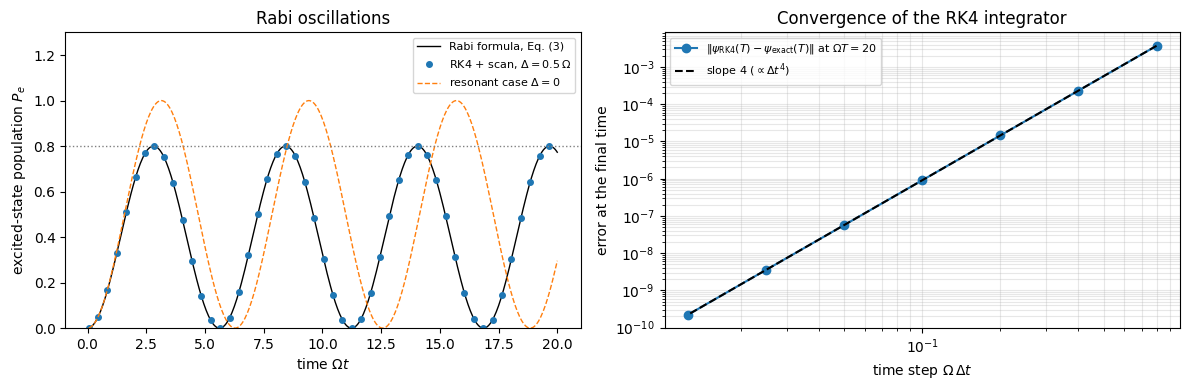

In [37]:
# ==============================================================================
# STEP 2: convergence study  error(dt)  and the figure
# ==============================================================================
step_counts = [25, 50, 100, 200, 400, 800, 1600]
conv_dt, conv_err = [], []
solver = jax.jit(rabi_trajectory, static_argnums=3)
for n in step_counts:
    psi_T = solver(OMEGA_TRUE, DELTA_TRUE, T_MAX / n, n)[-1]
    conv_dt.append(T_MAX / n)
    conv_err.append(float(jnp.linalg.norm(psi_T - psi_exact(T_MAX, OMEGA_TRUE, DELTA_TRUE))))   # error of the STATE
conv_dt, conv_err = np.array(conv_dt), np.array(conv_err)
# fit the slope only where truncation error dominates (single precision hits its round-off floor ~1e-6 early)
fit_range = slice(1, 6) if PRECISION == "double" else slice(0, 3)
slope = np.polyfit(np.log(conv_dt[fit_range]), np.log(conv_err[fit_range]), 1)[0]
print("dt    :", "  ".join(f"{d:9.4f}" for d in conv_dt))
print("error :", "  ".join(f"{e:9.2e}" for e in conv_err))
print(f"fitted order of convergence (dt = {conv_dt[fit_range][0]:g} ... {conv_dt[fit_range][-1]:g}): {slope:.2f}   (RK4 theory: 4)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(times, p_ref, "k-", lw=1, label="Rabi formula, Eq. (3)")
ax.plot(times[::8], p_num[::8], "o", ms=4, color="C0", label=rf"RK4 + scan, $\Delta={DELTA_TRUE}\,\Omega$")
ax.plot(times, p_excited_exact(times, OMEGA_TRUE, 0.0), "--", color="C1", lw=1, label=r"resonant case $\Delta=0$")
ax.axhline(OMEGA_TRUE**2 / (OMEGA_TRUE**2 + DELTA_TRUE**2), color="gray", ls=":", lw=1)
ax.set_xlabel(r"time $\Omega t$")
ax.set_ylabel(r"excited-state population $P_e$")
ax.set_title("Rabi oscillations")
ax.legend(fontsize=8, loc="upper right")
ax.set_ylim(0, 1.3)

ax = axes[1]
ax.loglog(conv_dt, conv_err, "o-", label=r"$\|\psi_{\rm RK4}(T) - \psi_{\rm exact}(T)\|$ at $\Omega T=20$")
ax.loglog(conv_dt, conv_err[3] * (conv_dt / conv_dt[3]) ** 4, "k--", label=r"slope 4 ($\propto\Delta t^4$)")
ax.set_xlabel(r"time step $\Omega\,\Delta t$")
ax.set_ylabel("error at the final time")
ax.set_title("Convergence of the RK4 integrator")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

assert 3.5 < slope < 4.6

*Left*: the detuned atom ($\Delta=0.5\,\Omega$) oscillates faster than the resonant one and reaches only
$P_e^{\max}=\Omega^2/\Omega_R^2=0.8$ (dotted line); numerical points and formula coincide. *Right*: the error at the
final time — measured as the norm of the difference between the numerical state and the exact state of Eq. (2) —
falls on a line of slope 4 in the log–log plot over almost two decades of $\Delta t$: halving the step gains a
factor 16. (With `PRECISION = "single"` the line would flatten at $\sim10^{-6}$, the round-off floor of 7-digit
arithmetic accumulated over hundreds of steps — try it.) A measured convergence order that agrees with theory is one of the strongest tests of an integrator:
bugs almost always destroy it.

> **Numerical practice.** Measure convergence on the *state*, not on a single observable at a single time. The
> error of $P_e(T)$ alone can vanish accidentally (the numerical and exact curves cross), which produces a ragged
> convergence plot and a meaningless fitted slope.

### 13.3 Parameter sweep with `vmap`: the Rabi chevron
Experimentalists calibrate a qubit by scanning the drive frequency (the detuning) and the pulse length, and
plotting $P_e(t,\Delta)$ as a colour map. We produce this map by `vmap`-ing our solver over $\Delta$. Nothing in
`rabi_trajectory` needs to change.

161 detunings x 400 RK4 steps in 0.97 s (incl. compilation); max deviation from Eq. (3) on the grid: 2.31e-06


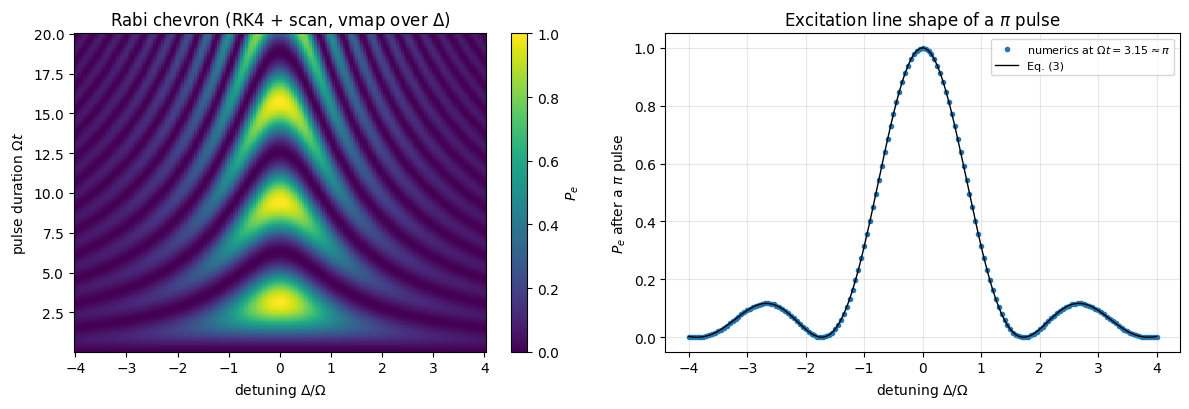

In [38]:
# ==============================================================================
# STEP 3: vmap over the detuning  ->  P_e(t, Delta)
# ==============================================================================
deltas = jnp.linspace(-4.0, 4.0, 161, dtype=RDTYPE)

sweep_delta = jax.jit(jax.vmap(rabi_trajectory, in_axes=(None, 0, None, None)), static_argnums=3)
t0 = time.perf_counter()
psis_sweep = sweep_delta(OMEGA_TRUE, deltas, dt, N_STEPS).block_until_ready()       # shape (161, 400, 2)
t_sweep = time.perf_counter() - t0
p_map = jnp.abs(psis_sweep[:, :, 1]) ** 2                                           # (n_delta, n_times)

# CHECKPOINT on the whole grid against Eq. (3)
p_map_exact = p_excited_exact(times[None, :], OMEGA_TRUE, deltas[:, None])
err_map = float(jnp.max(jnp.abs(p_map - p_map_exact)))
print(f"{len(deltas)} detunings x {N_STEPS} RK4 steps in {t_sweep:.2f} s (incl. compilation); "
      f"max deviation from Eq. (3) on the grid: {err_map:.2e}")
assert err_map < 1e-4

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
im = ax.pcolormesh(np.asarray(deltas), np.asarray(times), np.asarray(p_map).T, cmap="viridis", shading="auto", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label=r"$P_e$")
ax.set_xlabel(r"detuning $\Delta/\Omega$")
ax.set_ylabel(r"pulse duration $\Omega t$")
ax.set_title("Rabi chevron (RK4 + scan, vmap over $\\Delta$)")

ax = axes[1]
i_pi = int(np.argmin(np.abs(np.asarray(times) - np.pi)))                             # time step closest to t = pi/Omega
ax.plot(deltas, p_map[:, i_pi], "o", ms=3, label=rf"numerics at $\Omega t={float(times[i_pi]):.2f}\approx\pi$")
ax.plot(deltas, p_excited_exact(times[i_pi], OMEGA_TRUE, deltas), "k-", lw=1, label="Eq. (3)")
ax.set_xlabel(r"detuning $\Delta/\Omega$")
ax.set_ylabel(r"$P_e$ after a $\pi$ pulse")
ax.set_title(r"Excitation line shape of a $\pi$ pulse")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Left*: the **chevron** pattern known from countless experimental papers on superconducting qubits, trapped ions and
Rydberg atoms. On resonance the fringes are slow and have full contrast; with growing $|\Delta|$ they become faster
($\Omega_R=\sqrt{\Omega^2+\Delta^2}$) and fainter ($\Omega^2/\Omega_R^2$), which bends them into the characteristic
V shapes. *Right*: a horizontal cut at the $\pi$-pulse duration — the excitation probability as a function of the
drive frequency. Its central peak has a width of order $\Omega$ ("power broadening": a short, strong pulse is
spectrally broad), and the side lobes are those of a square pulse. The solver handled the whole batch of 161
detunings as one compiled program.

### 13.4 Fitting the Rabi frequency with `grad` — differentiating through the ODE solver
Now the inverse problem, a routine task in a laboratory: from measured populations, **infer** $\Omega$ and $\Delta$.

*Synthetic experiment.* At each of $K=40$ pulse durations $t_k$ the experiment is repeated $N_{\rm shots}=200$
times; every repetition ends with a projective measurement that yields "excited" with probability $P_e(t_k)$.
The recorded fraction $\hat P_k=n_k/N_{\rm shots}$ is therefore a binomial random variable with mean $P_e(t_k)$ and
standard deviation $\sqrt{P_e(1-P_e)/N_{\rm shots}}\le0.035$ — the *quantum projection noise* (shot noise).

*Model and cost function.* The model prediction $P_e^{\rm model}(t_k;\Omega,\Delta)$ is obtained **by running our
RK4 solver**, and the cost is the mean squared residual

$$ \mathcal L(\Omega,\Delta)=\frac1K\sum_{k=1}^{K}\big[P_e^{\rm model}(t_k;\Omega,\Delta)-\hat P_k\big]^2 .$$

We deliberately do *not* use the closed formula in the model: in research problems there is none. `jax.grad`
differentiates through all the RK4 steps inside the `scan` and delivers $\partial\mathcal L/\partial\Omega$ and
$\partial\mathcal L/\partial\Delta$, exact to round-off, for roughly the cost of two or three simulations.
The parameters live in a dict (a pytree, Section 11).

In [39]:
# ==============================================================================
# PARAMETERS of the synthetic experiment and of the fit
# ==============================================================================
N_DATA = 40                      # number of pulse durations t_k
DT_DATA = 0.25                   # spacing of the t_k  (t_k = 0.25, 0.50, ..., 10.0)
N_SUB = 1                        # RK4 sub-steps between two data times  -> dt = 0.25 (coarse on purpose, see below)
N_SHOTS = 200                    # repetitions per pulse duration
LEARNING_RATE = 0.2              # gradient-descent step (see the stability remark below Step 5)
N_FIT_STEPS = 150                # gradient-descent iterations

# ==============================================================================
# STEP 4: synthetic data, model, loss
# ==============================================================================
t_data = DT_DATA * jnp.arange(1, N_DATA + 1, dtype=RDTYPE)


def make_data(key):
    """Simulated measurement record: binomial counts with the exact probabilities P_e(t_k), divided by N_SHOTS.

    IMPLEMENTATION  N_SHOTS uniform random numbers per time point; a shot counts as 'excited' if u < P_e.
    """
    p = p_excited_exact(t_data, OMEGA_TRUE, DELTA_TRUE)
    u = jax.random.uniform(key, (N_SHOTS, N_DATA), dtype=RDTYPE)
    return jnp.mean(u < p[None, :], axis=0)


def model(params):
    """P_e at the data times from the RK4 solver; params = {'omega': ..., 'delta': ...} (a pytree)."""
    psis = rabi_trajectory(params["omega"], params["delta"], DT_DATA / N_SUB, N_DATA * N_SUB)
    return jnp.abs(psis[N_SUB - 1::N_SUB, 1]) ** 2            # keep every N_SUB-th step = the data times


def loss(params, data):
    """Mean squared residual between the simulated and the measured populations."""
    return jnp.mean((model(params) - data) ** 2)


data = make_data(jax.random.PRNGKey(7))
true_params = {"omega": jnp.asarray(OMEGA_TRUE, RDTYPE), "delta": jnp.asarray(DELTA_TRUE, RDTYPE)}
print("model vs Eq. (3) at the true parameters, max deviation:",
      f"{float(jnp.max(jnp.abs(model(true_params) - p_excited_exact(t_data, OMEGA_TRUE, DELTA_TRUE)))):.1e}")
print(f"loss at the true parameters: {float(loss(true_params, data)):.3e}   "
      f"(expected shot-noise level <P(1-P)>/N_SHOTS = "
      f"{float(jnp.mean(p_excited_exact(t_data, OMEGA_TRUE, DELTA_TRUE) * (1 - p_excited_exact(t_data, OMEGA_TRUE, DELTA_TRUE)))) / N_SHOTS:.3e})")

model vs Eq. (3) at the true parameters, max deviation: 1.3e-05


loss at the true parameters: 8.287e-04   (expected shot-noise level <P(1-P)>/N_SHOTS = 8.550e-04)


Even at the true parameters the loss is not zero: it equals the mean variance of the shot noise,
$\langle P_e(1-P_e)\rangle/N_{\rm shots}$, within statistical fluctuations. The coarse step $\Delta t=0.25$ used in
the model is accurate to about $10^{-5}$ — three orders of magnitude below the shot noise of $\approx0.03$ per
point, so a finer step would buy nothing. *Match the numerical accuracy to the accuracy of the data.*

**Checkpoint for the gradient.** Before trusting an optimiser we verify the gradient obtained by differentiating
*through the solver* in two independent ways: (a) against `grad` of a loss built from the closed formula (3), and
(b) against central finite differences with $h=10^{-5}$ (near the bottom of the V of Section 9.2).

In [40]:
# ==============================================================================
# CHECKPOINT: gradient through the ODE solver vs analytic-formula gradient vs finite differences
# ==============================================================================
def loss_formula(params, data):
    """Same loss, but with the closed Rabi formula as the model (reference only)."""
    return jnp.mean((p_excited_exact(t_data, params["omega"], params["delta"]) - data) ** 2)


guess = {"omega": jnp.asarray(1.3, RDTYPE), "delta": jnp.asarray(0.2, RDTYPE)}
g_solver = jax.grad(loss)(guess, data)
g_formula = jax.grad(loss_formula)(guess, data)

h = 1e-5 if PRECISION == "double" else 1e-2
g_fd = {}
for name in guess:
    plus = {**guess, name: guess[name] + h}
    minus = {**guess, name: guess[name] - h}
    g_fd[name] = (loss(plus, data) - loss(minus, data)) / (2 * h)

for name in guess:
    print(f"dL/d{name}:  AD through RK4+scan {float(g_solver[name]):+.10f} | AD of Eq.(3) {float(g_formula[name]):+.10f}"
          f" | finite differences {float(g_fd[name]):+.10f}")
    assert abs(g_solver[name] - g_fd[name]) < (1e-8 if PRECISION == "double" else 1e-2)
    assert abs(g_solver[name] - g_formula[name]) < 1e-3

dL/domega:  AD through RK4+scan +0.7605227901 | AD of Eq.(3) +0.7605419467 | finite differences +0.7605227896
dL/ddelta:  AD through RK4+scan +0.0710519891 | AD of Eq.(3) +0.0710528771 | finite differences +0.0710519891


Automatic differentiation through the 40 RK4 steps agrees with finite differences of the *same* loss to about
$10^{-9}$ (the accuracy of the finite differences, not of AD), and with the gradient of the closed-formula loss up
to the small discretisation error of the solver.

**The loss landscape.** Gradient descent only finds the *nearest* minimum. A loss built
from oscillating signals is notoriously non-convex: if the trial frequency is far off, model and data drift in and
out of phase. One more `vmap` shows the landscape along $\Omega$.

In [41]:
# ==============================================================================
# STEP 5: loss landscape (vmap over a grid), coarse global search, then gradient descent
# ==============================================================================
omega_grid = jnp.linspace(0.2, 3.0, 141, dtype=RDTYPE)
delta_grid = jnp.linspace(-2.4, 2.4, 161, dtype=RDTYPE)
loss_on_grid = jax.jit(jax.vmap(jax.vmap(lambda o, d: loss({"omega": o, "delta": d}, data),
                                         in_axes=(None, 0)), in_axes=(0, None)))
landscape = loss_on_grid(omega_grid, delta_grid)              # shape (141, 161)

i_best, j_best = np.unravel_index(int(jnp.argmin(landscape)), landscape.shape)
print(f"coarse grid minimum: Omega = {float(omega_grid[i_best]):.3f}, |Delta| = {abs(float(delta_grid[j_best])):.3f}"
      "   (the landscape is mirror symmetric in Delta -- see the discussion below)")

# stability of gradient descent: steps are stable only if  LEARNING_RATE < 2 / (largest Hessian eigenvalue)
hess = jax.hessian(loss)(true_params, data)                   # a pytree of second derivatives (dict of dicts)
hess_matrix = np.array([[float(hess[a][b]) for b in ("omega", "delta")] for a in ("omega", "delta")])
curvatures = np.linalg.eigvalsh(hess_matrix)
print(f"Hessian eigenvalues at the true parameters: {curvatures[0]:.2f}, {curvatures[1]:.2f}  ->  gradient descent is stable for "
      f"learning rates below 2/{curvatures[1]:.2f} = {2 / curvatures[1]:.2f}  (we use {LEARNING_RATE})")


@jax.jit
def fit(data, init):
    """Gradient descent on the loss;  returns (fitted parameter dict, (loss history, parameter path)).

    JAX   scan over iterations; value_and_grad differentiates through the inner scan of the RK4 solver;
          jax.tree.map updates every leaf of the parameter dict.
    """
    def step(params, _):
        value, grads = jax.value_and_grad(loss)(params, data)
        params = jax.tree.map(lambda p, g: p - LEARNING_RATE * g, params, grads)
        return params, (value, params)                         # record the loss and the path through parameter space

    return lax.scan(step, init, None, length=N_FIT_STEPS)


init_good = {"omega": jnp.asarray(1.2, RDTYPE), "delta": jnp.asarray(0.2, RDTYPE)}
init_bad = {"omega": jnp.asarray(2.4, RDTYPE), "delta": jnp.asarray(0.2, RDTYPE)}
fit_good, (hist_good, path_good) = fit(data, init_good)
fit_bad, (hist_bad, path_bad) = fit(data, init_bad)
print(f"start (1.2, +0.2) -> Omega = {float(fit_good['omega']):.4f}, Delta = {float(fit_good['delta']):+.4f}, "
      f"final loss {float(hist_good[-1]):.3e}")
print(f"start (2.4, +0.2) -> Omega = {float(fit_bad['omega']):.4f}, Delta = {float(fit_bad['delta']):+.4f}, "
      f"final loss {float(hist_bad[-1]):.3e}   <- wrong basin: never reaches the true minimum")
print(f"true values          Omega = {OMEGA_TRUE:.4f}, Delta = {DELTA_TRUE:+.4f}")

coarse grid minimum: Omega = 1.000, |Delta| = 0.510   (the landscape is mirror symmetric in Delta -- see the discussion below)


Hessian eigenvalues at the true parameters: 0.44, 6.07  ->  gradient descent is stable for learning rates below 2/6.07 = 0.33  (we use 0.2)


start (1.2, +0.2) -> Omega = 0.9958, Delta = +0.5014, final loss 7.991e-04
start (2.4, +0.2) -> Omega = 2.0188, Delta = +1.3834, final loss 1.373e-01   <- wrong basin: never reaches the true minimum
true values          Omega = 1.0000, Delta = +0.5000


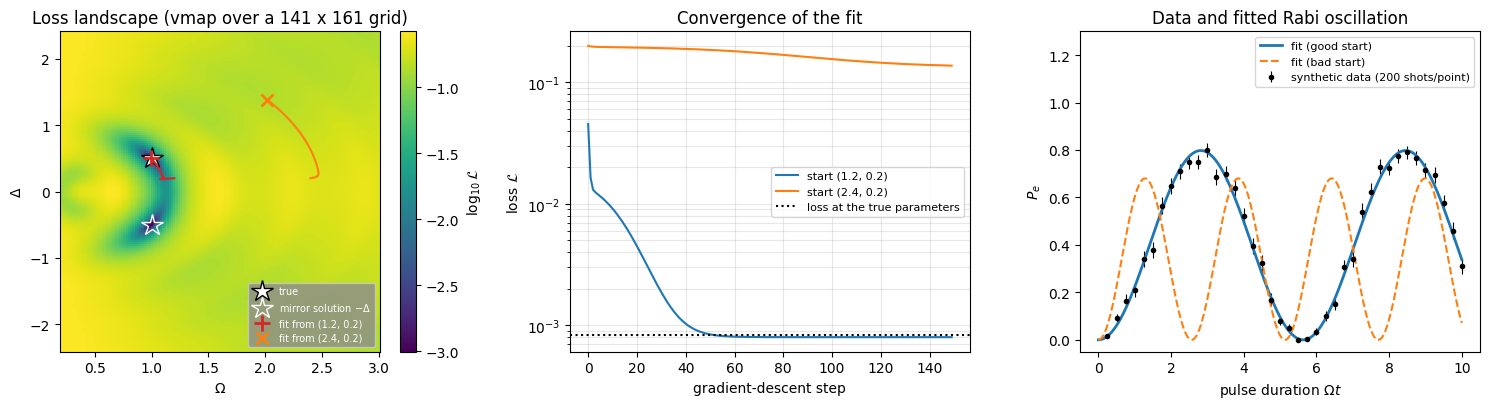

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
im = ax.pcolormesh(np.asarray(omega_grid), np.asarray(delta_grid), np.log10(np.asarray(landscape)).T, cmap="viridis", shading="auto")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\mathcal{L}$")
ax.plot(OMEGA_TRUE, DELTA_TRUE, "*", color="w", ms=16, mec="k", label="true")
ax.plot(OMEGA_TRUE, -DELTA_TRUE, "*", color="none", ms=16, mec="w", label=r"mirror solution $-\Delta$")
ax.plot(np.r_[1.2, np.asarray(path_good["omega"])], np.r_[0.2, np.asarray(path_good["delta"])], "-", color="C3", lw=1.5)
ax.plot(float(fit_good["omega"]), float(fit_good["delta"]), "+", color="C3", ms=11, mew=2, label="fit from (1.2, 0.2)")
ax.plot(np.r_[2.4, np.asarray(path_bad["omega"])], np.r_[0.2, np.asarray(path_bad["delta"])], "-", color="C1", lw=1.5)
ax.plot(float(fit_bad["omega"]), float(fit_bad["delta"]), "x", color="C1", ms=9, mew=2, label="fit from (2.4, 0.2)")
ax.set_xlabel(r"$\Omega$")
ax.set_ylabel(r"$\Delta$")
ax.set_title("Loss landscape (vmap over a 141 x 161 grid)")
ax.legend(fontsize=7, loc="lower right", facecolor="0.55", labelcolor="w")

ax = axes[1]
ax.semilogy(hist_good, label="start (1.2, 0.2)")
ax.semilogy(hist_bad, label="start (2.4, 0.2)")
ax.axhline(float(loss(true_params, data)), color="k", ls=":", label="loss at the true parameters")
ax.set_xlabel("gradient-descent step")
ax.set_ylabel(r"loss $\mathcal{L}$")
ax.set_title("Convergence of the fit")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

ax = axes[2]
t_fine = jnp.linspace(0, float(t_data[-1]), 300)
sigma_shot = np.sqrt(np.clip(np.asarray(data) * (1 - np.asarray(data)), 1e-3, None) / N_SHOTS)
ax.errorbar(t_data, data, yerr=sigma_shot, fmt="o", ms=3, color="k", elinewidth=0.8, label=f"synthetic data ({N_SHOTS} shots/point)")
ax.plot(t_fine, p_excited_exact(t_fine, fit_good["omega"], fit_good["delta"]), "C0-", lw=2, label="fit (good start)")
ax.plot(t_fine, p_excited_exact(t_fine, fit_bad["omega"], fit_bad["delta"]), "C1--", lw=1.5, label="fit (bad start)")
ax.set_xlabel(r"pulse duration $\Omega t$")
ax.set_ylabel(r"$P_e$")
ax.set_title("Data and fitted Rabi oscillation")
ax.legend(fontsize=8, loc="upper right")
ax.set_ylim(-0.05, 1.3)
plt.tight_layout()
plt.show()

*Left*: the landscape (colour = $\log_{10}\mathcal L$, dark = small) has a deep, narrow, banana-shaped valley
around the true parameters and shallow local minima elsewhere; the thin lines are the paths taken by gradient
descent. It is exactly symmetric under $\Delta\to-\Delta$ — Eq. (3) contains only $\Delta^2$, so **the sign of the detuning cannot be
learned from $P_e(t)$**; the open star marks the mirror solution. An experimentalist fixes the sign with a
frequency scan as in the chevron: the centre of the symmetric pattern locates $\omega_0$, and the known drive
frequency $\omega$ then gives the sign of $\Delta=\omega-\omega_0$. *Middle*: started close enough, gradient descent brings the loss down to the shot-noise level, slightly
*below* the loss of the true parameters, as it should be for a least-squares fit, which also fits a bit of the noise.
Started at $\Omega=2.4$ it never finds that valley: it creeps along a shallow side valley towards a local minimum
whose loss is more than a hundred times larger. *Right*: the good fit follows the data; the trapped one oscillates
at a wrong frequency and cannot follow the data.

The printed Hessian eigenvalues explain the choice of the learning rate. Near a minimum the loss is a quadratic
bowl; along an eigen-direction with curvature $\lambda$ one gradient step multiplies the distance to the minimum by
$(1-\eta\lambda)$. The iteration is stable only if $|1-\eta\lambda_{\max}|<1$, i.e. $\eta<2/\lambda_{\max}$, while the
*slowest* direction converges at the rate $(1-\eta\lambda_{\min})$ per step. The ratio
$\lambda_{\max}/\lambda_{\min}$ (the condition number, here $\approx 14$) therefore dictates how many iterations plain
gradient descent needs, and it is the reason for the better optimisers of
[41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb).

> **Numerical practice.** A robust fitting workflow is *global, then local*: a coarse scan of the landscape (cheap
> with `vmap`) to find the right basin, then gradient-based refinement. Always compare the final loss with the noise
> level you expect — a loss far above it signals a local minimum or a wrong model.

### 13.5 Statistics of the fit from 200 repeated experiments
A single fit gives numbers without error bars. The cleanest way to obtain the statistical uncertainty is to repeat
the *entire* procedure — generate data, fit — for many independent noise realisations and look at the scatter of the
results. `fit` is a pure function of `(data, init)`, so this is one more `vmap`: a batch of 200 gradient
descents, each differentiating through its own ODE solutions, all inside a single compiled program:
`jit(vmap(scan(grad(scan(rk4)))))`.

200 complete fits (150 gradient steps each) in 7.9 s including compilation
Omega   : mean 1.0001  std 0.0057   (true 1.0)
Delta   : mean 0.5000  std 0.0098   (true 0.5; 200 of 200 fits have Delta > 0)
Omega_R : mean 1.1182  std 0.0026   (true 1.1180)
relative scatter: Omega 0.57 %,  Delta 1.97 %,  Omega_R 0.24 %


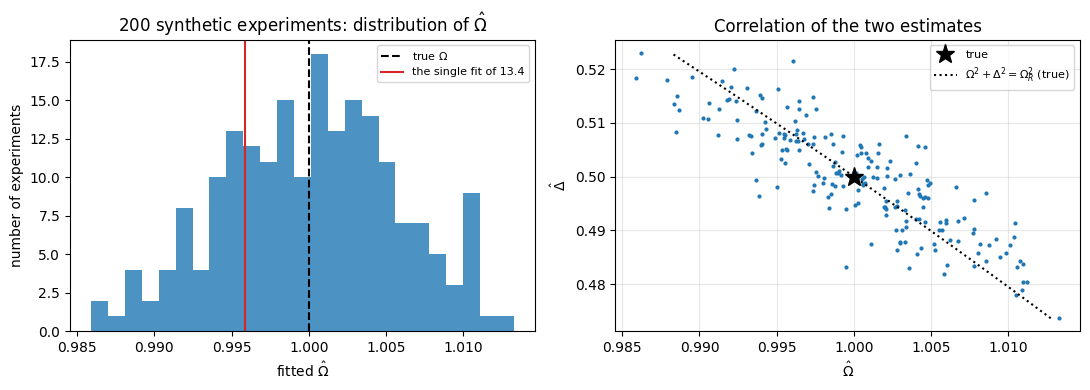

In [43]:
# ==============================================================================
# STEP 6: statistics of the estimator from 200 independent synthetic experiments
# ==============================================================================
N_EXPERIMENTS = 200
exp_keys = jax.random.split(jax.random.PRNGKey(123), N_EXPERIMENTS)
all_data = jax.vmap(make_data)(exp_keys)                                        # (200, 40)

t0 = time.perf_counter()
all_fits, _ = jax.jit(jax.vmap(fit, in_axes=(0, None)))(all_data, init_good)    # dict of arrays of shape (200,)
jax.block_until_ready(all_fits)
t_fits = time.perf_counter() - t0

om_hat, de_hat = np.asarray(all_fits["omega"]), np.asarray(all_fits["delta"])
om_r_hat = np.sqrt(om_hat**2 + de_hat**2)
print(f"{N_EXPERIMENTS} complete fits ({N_FIT_STEPS} gradient steps each) in {t_fits:.1f} s including compilation")
print(f"Omega   : mean {om_hat.mean():.4f}  std {om_hat.std():.4f}   (true {OMEGA_TRUE})")
print(f"Delta   : mean {de_hat.mean():.4f}  std {de_hat.std():.4f}   (true {DELTA_TRUE}; "
      f"{np.sum(de_hat > 0)} of {N_EXPERIMENTS} fits have Delta > 0)")
print(f"Omega_R : mean {om_r_hat.mean():.4f}  std {om_r_hat.std():.4f}   (true {np.hypot(OMEGA_TRUE, DELTA_TRUE):.4f})")
print(f"relative scatter: Omega {100 * om_hat.std() / OMEGA_TRUE:.2f} %,  Delta {100 * de_hat.std() / DELTA_TRUE:.2f} %,  "
      f"Omega_R {100 * om_r_hat.std() / np.hypot(OMEGA_TRUE, DELTA_TRUE):.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.hist(om_hat, bins=25, color="C0", alpha=0.8)
ax.axvline(OMEGA_TRUE, color="k", ls="--", label=r"true $\Omega$")
ax.axvline(float(fit_good["omega"]), color="C3", label="the single fit of 13.4")
ax.set_xlabel(r"fitted $\hat\Omega$")
ax.set_ylabel("number of experiments")
ax.set_title(rf"{N_EXPERIMENTS} synthetic experiments: distribution of $\hat\Omega$")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(om_hat, de_hat, ".", ms=4)
ax.plot(OMEGA_TRUE, DELTA_TRUE, "k*", ms=14, label="true")
dd = np.linspace(de_hat.min(), de_hat.max(), 100)
ax.plot(np.sqrt(np.hypot(OMEGA_TRUE, DELTA_TRUE) ** 2 - dd**2), dd, "k:", label=r"$\Omega^2+\Delta^2=\Omega_R^2$ (true)")
ax.set_xlabel(r"$\hat\Omega$")
ax.set_ylabel(r"$\hat\Delta$")
ax.set_title("Correlation of the two estimates")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# CHECKPOINT: no bias visible at the resolution of 200 repetitions.  The threshold is 5 standard errors of the
# mean (5 * std / sqrt(200) = 2e-3 here) plus 1e-3 of slack, so that the check also survives PRECISION="single".
assert abs(om_hat.mean() - OMEGA_TRUE) < 5 * om_hat.std() / np.sqrt(N_EXPERIMENTS) + 1e-3
assert np.all(np.isfinite(om_hat)) and np.all(de_hat > 0)     # every fit stayed in the basin of +DELTA_TRUE

The histogram of $\hat\Omega$ is centred on the true value, and its width is the error bar of a *single*
experiment with $40\times200$ shots (the red line — our fit from 13.4 — is one draw from this distribution).
"Centred" is a statement with a resolution: $200$ repetitions locate the mean only to
$\sigma_{\hat\Omega}/\sqrt{200}\approx4\times10^{-4}$, and no bias shows up at that level. Least squares applied to
a *non-linear* model is in general only asymptotically unbiased: its bias is of the order of the variance of the
estimate, $\sigma_{\hat\Omega}^2\approx3\times10^{-5}$, far below what we could see here.
The scatter plot reveals structure that a single fit hides: $\hat\Omega$ and $\hat\Delta$ are **anti-correlated**
along the circle $\Omega^2+\Delta^2=\Omega_R^2$. The data pin down the oscillation *frequency* $\Omega_R$ very
precisely (relative scatter $\approx0.2\,\%$, against $\approx0.6\,\%$ for $\Omega$ and $\approx2\,\%$ for $\Delta$) whereas
the *contrast* $\Omega^2/\Omega_R^2$, which distributes $\Omega_R$ between $\Omega$ and $\Delta$, is blurred by shot
noise. A frequency is fixed by the positions of many oscillation periods, which is why frequencies are among the
most precisely measured quantities in physics. None of the transformations used here required a change to
`rabi_trajectory`, which was written for one atom and one parameter set.

## 14. Cheat sheets

### 14.1 NumPy habit → JAX idiom

| NumPy habit | JAX idiom | why |
|---|---|---|
| `import numpy as np` | `import jax.numpy as jnp` (keep `np` for set-up and I/O) | same interface, compilable |
| `x[i] = v`, `x[i] += v` | `x = x.at[i].set(v)`, `x = x.at[i].add(v)` | arrays are immutable; pure functions |
| `np.zeros(n)` is `float64` | set `jax_enable_x64` (our Configuration cell), use `dtype=RDTYPE/CDTYPE` | JAX defaults to 32 bit |
| `np.random.seed(0); np.random.rand(3)` | `key = jax.random.PRNGKey(0); key, sub = jax.random.split(key); jax.random.uniform(sub, (3,))` | explicit, reproducible, parallelisable randomness |
| `for` loop over samples / parameters | `jax.vmap(f, in_axes=...)` | batching without rewriting `f` |
| `for` loop over time steps | `lax.scan(step, carry, xs)` | compiled once, not unrolled |
| `while not converged:` | `lax.while_loop(cond, body, state)` | data-dependent loop inside compiled code |
| `if x > 0: ... else: ...` on array values | `jnp.where(x > 0, a, b)` or `lax.cond(...)` | tracers have no value at trace time |
| `a and b`, `a or b` on arrays | `a & b`, `a \| b` | same reason |
| finite-difference gradients | `jax.grad(f)`, `jax.value_and_grad(f)` | exact, cost independent of the number of parameters |
| hand-vectorised batch code with extra axes | single-sample function + `vmap` | readable, testable |
| global variables used inside functions | pass everything as arguments | globals are frozen at trace time |
| `print(x)` for debugging inside a function | `jax.debug.print("x = {}", x)` | `print` runs only at trace time |
| `time.time()` around a call | warm-up call, then `result.block_until_ready()` inside the timer | asynchronous dispatch; compile time $\ne$ run time |
| `x[[0, 2]]` with a list of lists / `np.sum([1, 2])` | `x[jnp.array([0, 2])]` / `jnp.sum(jnp.array([1, 2]))` | no implicit list conversion |
| index out of range raises `IndexError` | silently clamped (read) or dropped (update) | no exceptions on accelerators — test your indices |

### 14.2 Common error messages and what they mean

| message (abridged) | what happened | cure |
|---|---|---|
| `TypeError: JAX arrays are immutable and do not support in-place item assignment` | `x[i] = v` | `x = x.at[i].set(v)` |
| `TracerBoolConversionError: Attempted boolean conversion of traced array` | Python `if`/`while`/`and`/`or` on a value computed from a jitted function's arguments | `jnp.where`, `lax.cond`, `&`/`\|`; or make the argument static if it is structure |
| `TracerIntegerConversionError: The __index__() method was called on traced array` | a traced value used in `range(n)`, as a list index or as a Python int | `static_argnums` / `static_argnames`, or `lax.scan`/`lax.fori_loop` |
| `TypeError: Shapes must be 1D sequences of concrete values of integer type` | a traced value used as a *shape* (`jnp.zeros(n)`) | make `n` static; shapes must be known at compile time |
| `TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array` | a NumPy function (`np.sin`, `np.asarray`, `float()`) applied to a tracer | use the `jnp` function; convert to NumPy only outside `jit` |
| `ConcretizationTypeError` | same family: a concrete value was required from a tracer | as above |
| `UserWarning: Explicitly requested dtype float64 ... will be truncated to dtype float32` | 64-bit mode is off | `jax.config.update("jax_enable_x64", True)` at start-up (our Configuration cell) |
| `TypeError: grad requires real- or complex-valued inputs ... but got int` | differentiating w.r.t. an integer array | pass floats: `jnp.arange(3.0)`, `x.astype(RDTYPE)` |
| `TypeError: Gradient only defined for scalar-output functions` | `grad` of a vector-valued function | reduce to a scalar (sum, energy, loss) or use `jax.jacobian` |
| `TypeError: grad requires real-valued outputs ... but got complex` | the cost function returns a complex number | take `jnp.real(...)` / `jnp.abs(...)**2` of the physical quantity |
| `ValueError: vmap got inconsistent sizes for array axes to be mapped` | batched arguments with different batch sizes | check `in_axes`; use `None` for shared arguments |
| `TypeError: scan body function carry input and carry output must have equal types` | the carry changes dtype/shape during the step | initialise the carry with the final dtype (`jnp.zeros((), RDTYPE)`) |
| `ValueError: Non-hashable static arguments` | an array was declared static | only ints/strings/tuples can be static; pass arrays as traced arguments |
| `TypeError: sin requires ndarray or scalar arguments, got <class 'list'>` | a Python list handed to a `jnp` function | wrap in `jnp.array(...)` |
| gradient is `nan` although the value is fine | `jnp.where` with an unsafe unselected branch (`sqrt(0)`, `log(0)`, `x/0`) | the "double where" of Section 9.3 |
| everything is mysteriously slow | recompilation at every call (changing shapes, static floats, `jax.jit` called inside a loop) or timing without warm-up | fix shapes, create the jitted function once, use `bench`-style timing |

## 15. Summary — key takeaways

* **JAX = NumPy interface + XLA compiler + function transformations.** Code is written as *pure functions* of
  immutable arrays; updates use `x.at[i].set(v)`.
* **Precision is a decision.** JAX defaults to `float32`; the course's Configuration cell enables 64-bit and
  derives `RDTYPE`, `CDTYPE`, `TOL` from one switch. Never hard-code dtypes.
* **`jit`** traces a function once per input shape/dtype and compiles it; tracers carry no values, hence: no Python
  `if` on data (use `jnp.where`/`lax.cond`), structure as *static* arguments, no reliance on globals or `print`.
* **`vmap`** batches a single-sample function (parameter sweeps, shots, trajectories, fits); **`lax.scan`** is the
  compiled loop with a carry (time evolution, iterations, optimisation loops).
* **`grad`** gives exact gradients at a cost independent of the number of parameters — even through an ODE solver.
  Finite differences are limited by the truncation/round-off trade-off and serve as an independent check.
* **Randomness is explicit**: a key in, numbers out; split, never reuse. Statistical errors fall as $1/\sqrt{M}$.
* **Benchmarking**: warm up (compile), `block_until_ready`, report best-of-several, quote ratios and scaling.
* **Physics**: the driven two-level atom, $P_e(t)=\frac{\Omega^2}{\Omega_R^2}\sin^2(\Omega_R t/2)$ with
  $\Omega_R=\sqrt{\Omega^2+\Delta^2}$; the chevron; $P_e(t)$ determines $\Omega_R$ precisely, $|\Delta|$ less so,
  and the sign of $\Delta$ not at all.
* **Working habit**: every numerical result above was compared with an independent reference (analytic formula,
  NumPy, finite differences, a second algorithm).

## 16. Exercises

1. ★ **Functional updates.** Build the $4\times4$ matrix with ones on the anti-diagonal starting from
   `jnp.zeros((4, 4), dtype=CDTYPE)` and using only `.at[].set()`. Verify with `jnp.allclose` against
   `jnp.fliplr(jnp.eye(4))`. Then predict — before running — the output of `jnp.arange(4.0)[7]` and of
   `jnp.arange(4.0).at[7].add(1.0)`.
2. ★ **Recompilation detective.** Put a Python `print("tracing")` into a jitted function of `(x, n)` with `n`
   static. Call it with (a) the same shapes and `n`, (b) a new `n`, (c) a `float32` instead of a `float64` array,
   (d) a Python float instead of an array. Explain each (non-)appearance of the message.
3. ★ **Timing `eigh`.** Time `jnp.linalg.eigh` for random symmetric matrices of size 100…1600 with `bench`, plot
   the time versus size on a log–log scale and extract the exponent. Compare with the expected $O(n^3)$ and with NumPy.
4. ★★ **Physics: $\pi$-pulse errors.** Using `rabi_trajectory` and `vmap`, compute the excitation probability after a
   nominal $\pi$ pulse as a function of a relative amplitude error $\epsilon$, $\Omega\to\Omega(1+\epsilon)$, at
   $\Delta=0$. Show numerically and from Eq. (3) that the infidelity $1-P_e$ grows *quadratically*,
   $\approx(\pi\epsilon/2)^2$, and find the corresponding law for a small detuning error.
5. ★★ **Extend the code: a shaped pulse.** Make the Rabi frequency time dependent, $\Omega(t)=\Omega_0\exp[-(t-t_c)^2/2\tau^2]$
   (the right-hand side now really depends on `t`; `integrate` already passes it). Verify on resonance that the final
   population depends only on the *pulse area*, $P_e=\sin^2\big(\tfrac12\int\Omega(t)\,dt\big)$. Why does this hold
   for $\Delta=0$ (hint: $H(t)$ commutes with itself at different times) and fail for $\Delta\neq0$?
6. ★★ **Unitary stepping.** Replace the RK4 step by the exact one-step propagator of Eq. (2),
   $U(\Delta t)=\cos(\Omega_R\Delta t/2)\mathbb 1-i\sin(\Omega_R\Delta t/2)\,\vec n\cdot\vec\sigma$, inside a `scan`.
   Compare norm conservation and accuracy with RK4 for $\Omega T=2000$. Which integrator would you trust for long
   times?
7. ★★ **Better optimiser.** Replace plain gradient descent in `fit` by gradient descent with momentum (carry =
   `(params, velocity)`, both pytrees). How many iterations do you save? Try also to fit with the initial guess
   $(2.4, 0.2)$ after *first* running the coarse grid search of Step 5 to initialise.
8. ★★★ **Cramér–Rao check.** For Gaussian noise of variance $\sigma_k^2=P_k(1-P_k)/N_{\rm shots}$ the covariance of
   any unbiased estimator is bounded below by the inverse of the Fisher matrix $F_{ab}=\sum_k \sigma_k^{-2}\,\partial_a P_k\,
   \partial_b P_k$. Obtain the derivatives $\partial P_k/\partial(\Omega,\Delta)$ with `jax.jacobian(model)`, compute
   $F^{-1}$, and compare its diagonal and its correlation coefficient with the scatter measured in Section 13.5.
   (Our loss is *unweighted*, so our estimator is not the maximum-likelihood one; find by how much it misses the
   bound.)

## 17. References

*JAX and its ideas*

* J. Bradbury, R. Frostig, P. Hawkins, M. J. Johnson, Y. Katariya, C. Leary, D. Maclaurin, G. Necula, A. Paszke,
  J. VanderPlas, S. Wanderman-Milne, Q. Zhang, *JAX: composable transformations of Python+NumPy programs* (2018), software,
  <https://github.com/jax-ml/jax>; documentation at <https://docs.jax.dev> — see in particular the chapters
  "🔪 JAX – The Sharp Bits 🔪", "Just-in-time compilation", "Automatic vectorization" and "Pseudorandom numbers".
* R. Frostig, M. J. Johnson, C. Leary, *Compiling machine learning programs via high-level tracing*, SysML Conference (2018).
* A. G. Baydin, B. A. Pearlmutter, A. A. Radul, J. M. Siskind, *Automatic differentiation in machine learning: a
  survey*, Journal of Machine Learning Research **18**(153), 1–43 (2018).
* J. K. Salmon, M. A. Moraes, R. O. Dror, D. E. Shaw, *Parallel random numbers: as easy as 1, 2, 3*, Proc. SC'11,
  ACM (2011), article 16, 1–12 — the counter-based "Threefry" generator behind `jax.random`.

*Numerics*

* W. H. Press, S. A. Teukolsky, W. T. Vetterling, B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed., Cambridge University Press (2007) — Runge–Kutta methods, numerical derivatives, Monte Carlo.
* D. Goldberg, *What every computer scientist should know about floating-point arithmetic*, ACM Computing Surveys
  **23**(1), 5–48 (1991).

*Physics*

* I. I. Rabi, *Space quantization in a gyrating magnetic field*, Physical Review **51**, 652 (1937).
* C. J. Foot, *Atomic Physics*, Oxford University Press (2005), Chapter 7 *The interaction of atoms with
  radiation*: the rotating-wave approximation, Rabi oscillations, $\pi$ pulses and the Bloch sphere.
* D. J. Griffiths, D. F. Schroeter, *Introduction to Quantum Mechanics*, 3rd ed., Cambridge University Press (2018)
  — Chapter 4 (spin 1/2) and Chapter 11 (*Quantum Dynamics*: two-level systems).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/